<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# Week 9 — Black-box Optimisation, Functions 1–8

** The first time all functions output above the initial max**

| # | Predictable Optimisation | Source of Emergent Behaviour | Balance | Robustness vs. Compute Cost | Trade-off Logic |
|:-------:|--------------------------|------------------------------|:--------:|:--------------------------:|-----------------|
| **F1** | GP with UCB/EI acquisition and Signed, monotonic transform | Exploration driven only by GP uncertainty | **Very Conservative** | **Low** | A simple and conservative approach. Because the objective has a large dynamic range, a poor query is costly, so uncertainty-guided exploration is preferred over aggressive exploitation. |
| **F2** | GP with Random Forest-informed kernel parameters | Adaptive kernel length scales learned from Random Forest partial dependence | **Mild Emergence** | **Low–Medium** | Further exploitation would likely rediscover the current optimum. The query is instead used to gain new information through exploration. |
| **F3** | ExtraTrees surrogate with polynomial feature expansion | Ensemble disagreement and nonlinear feature interactions | **Moderate** | **Medium** | The model is already confident, so distance filtering avoids selecting points close to previous evaluations, reducing the chance of wasting the query. |
| **F4** | GP with extensive diagnostic visualisations | Human interpretation of response surfaces guides subsequent exploration | **Conservative** | **Medium** | A previous failure, where very high uncertainty dominated the acquisition despite a poor predicted mean, motivated a robustness check. Alternative candidates are compared before selecting the final query. |
| **F5** | GP with constrained local and boundary search | Boundary pinning and structured perturbations alter search dynamics | **Moderate** | **Medium–High** | A two-stage pipeline improves efficiency: a cheaper model filters candidates first, allowing the more expensive optimiser to evaluate only the most promising ones. |
| **F6** | Random Forest surrogate with SHAP explainability | Feature importance explanations influence future search direction | **Moderate** | **High** | The surrogate model is selected using held-out validation rather than assumption. The additional computation improves confidence in exploiting the predicted optimum. |
| **F7** | Dataset filtering before Random Forest optimisation | Reshaping the optimisation landscape through adaptive data selection | **High** | **High** | Extra validation is used to ensure the exploration direction is reliable, since impurity-based feature importance can be misleading when features are correlated. |
| **F8** | Neural network surrogate with Monte Carlo dropout uncertainty | Learned latent representations and stochastic uncertainty estimates | **Highest** | **Highest** | The most computationally expensive approach, but it provides the strongest uncertainty estimates and supports the most confident and least conservative exploration strategy. |

In [1]:
# -----------------------------------------------------------------------------
# Imports
# -----------------------------------------------------------------------------

import warnings

import matplotlib.pyplot as plt
import numpy as np
import shap
import torch
import torch.nn as nn
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
from scipy.stats import norm, rankdata
from scipy.stats.qmc import LatinHypercube
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel,
    Matern,
    WhiteKernel,
)
from sklearn.inspection import (
    PartialDependenceDisplay,
    partial_dependence,
    permutation_importance,
)
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVC, SVR
from skopt.sampler import Lhs
from skopt.space import Space


# -----------------------------------------------------------------------------
# Warning configuration
# -----------------------------------------------------------------------------

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Helper Functions

In [2]:
# Upper Confidence Bound acquisition: reward predicted mean, 
# add a kappa-weighted uncertainty bonus to encourage exploration.
def compute_ucb(mu, sigma, kappa=2.5):
    return mu + kappa * sigma
 

# Expected Improvement acquisition: expected gain over the current best (f_best), 
# balancing predicted improvement against uncertainty.
def compute_ei(mu, sigma, f_best, xi=0.01):
    z = (mu - f_best - xi) / (sigma + 1e-9)
    ei = (mu - f_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma == 0] = 0
    return ei
 

# Format a candidate point as a clipped, fixed-decimal, 
# dash-separated string suitable for submitting as a query.
def format_query(point, decimals=6):
    point_clipped = np.clip(point, 0, 0.999999)
    return '-'.join([f'{x:.{decimals}f}' for x in point_clipped])


# Get an ensemble mean/std (mu, sigma) prediction from a Random Forest /
# ExtraTrees model by aggregating each tree's prediction.
def rf_mu_sigma(model, X_query):
    per_tree = np.stack([tree.predict(X_query) for tree in model.estimators_], axis=0)
    mu = per_tree.mean(axis=0)
    sigma = per_tree.std(axis=0)
    return mu, sigma
 

# Thompson sampling: draw posterior function samples from the GP 
# over a random subsample of candidates, and return the index of the best one.
def thompson_sample(gp, candidates, n_samples=10, subsample=500):
    idx = np.random.choice(len(candidates), size=min(subsample, len(candidates)), replace=False)
    sub = candidates[idx]
    samples = gp.sample_y(sub, n_samples=n_samples, random_state=42)
    best_sub_idx = np.argmax(samples.mean(axis=1))
    return idx[best_sub_idx]
 

# Monte Carlo dropout prediction: run the model in train() mode 
# (so dropout stays active) for multiple forward passes, and 
# use the mean/std across passes as the predicted value and its uncertainty.
def mc_predict(model, X_tensor, n_passes=50):
    model.train()
    preds = torch.stack([model(X_tensor).squeeze() for _ in range(n_passes)])
    return preds.mean(dim=0).detach().numpy(), preds.std(dim=0).detach().numpy()

# Function 1, Radiation field, 2D array, 10 original samples - Week 9

In [3]:
# =============================================================================
# Function 1, Radiation field, 2D array, 10 original samples
# =============================================================================
# Previous weeks
# W3: Two-stage strategy: EI balances predicted improvement and uncertainty, 
#      while the distance criterion explicitly promotes spatial diversity, producing an EI + diversity hybrid.
# W4: GP (Matérn ν = 2.5) on log₁₀ outputs + UCB (κ = 5.0, exploration-heavy) --- negative failure
# W5: GP (Matérn ν = 2.5, length scale fixed at 0.15) on log-transformed |outputs|; 
#     acquisition = UCB (κ = 4.0) over 10,000 random candidates
# W6: GP (Matérn, fixed length scale); Signal masking (drop |y| < 1e-30); UCB
# W7: GP (Matérn + White) on log-absolute outputs; UCB κ = 2 --- negative failure
# W8: GP (Matérn + White kernel, optimized hyperparameters) + UCB (κ = 0.5) on tight local candidates

# change: Leverage pure Gaussian Process uncertainty with a monotonic log-scale transform 
#         to prevent costly queries across a wide dynamic range.
 
print("=" * 60)
print("Function 1 - Week 9")
print("=" * 60)

f1_inputs  = np.load('initial_data/function_1/initial_inputs.npy')
f1_outputs = np.load('initial_data/function_1/initial_outputs.npy')

prev_queries_1 = np.array([
    [0.750000, 0.750000],              # W2
    [0.803076, 0.431805],              # W4
    [0.513943, 0.454749],              # W4 negative failure
    [0.994654, 0.996067],              # W5 (weak but genuine positive detection)
    [0.411304, 0.240532],              # W6
    [0.658199, 0.549042],              # W7 negative failure
    [0.736438, 0.744550],              # W8 return and close to initial
])
prev_outputs_1 = np.array([
    1.33E-22,      # W2
    2.04E-50,      # W3
    -3.89E-08,     # W4
    5.18E-188,     # W5
    8.07E-24,      # W6
    -7.45E-06,     # W7
    2.01E-19       # W8
])

all_inputs_F1 = np.vstack([f1_inputs, prev_queries_1])
all_outputs_F1 = np.hstack([f1_outputs, prev_outputs_1])
print(f"Total points: {len(all_outputs_F1)}")
print(f"Current best (max, raw signed value): {all_outputs_F1.max():.6e}")
print(f"  at input: {all_inputs_F1[np.argmax(all_outputs_F1)]}")
print(f"Current worst (min, raw signed value): {all_outputs_F1.min():.6e}")
print(f"  at input: {all_inputs_F1[np.argmin(all_outputs_F1)]}")


Function 1 - Week 9
Total points: 17
Current best (max, raw signed value): 7.710875e-16
  at input: [0.73102363 0.73299988]
Current worst (min, raw signed value): -3.606063e-03
  at input: [0.65011406 0.68152635]


In [4]:
# Function 1: the raw outputs span many orders of magnitude (including negative 'sink' values),
#  so apply a sign-preserving arcsinh transform to compress the dynamic range 
# while keeping zero-crossings meaningful for the GP. 
# Then verify the transform hasn't changed the relative ranking of points.

eps = 1e-20
signed_readings = np.arcsinh(all_outputs_F1 / eps)

order_raw = np.argsort(all_outputs_F1)[::-1]
order_transformed = np.argsort(signed_readings)[::-1]
assert np.array_equal(order_raw, order_transformed), "Transform must preserve raw ordering!"
print("Sanity check passed: transformed ranking matches raw output ranking.")
print(f"Signed-reading range: {signed_readings.min():.2f} to {signed_readings.max():.2f}")


Sanity check passed: transformed ranking matches raw output ranking.
Signed-reading range: -41.12 to 11.95


In [5]:
# Print every observed point sorted by raw output (best first), showing 
# both the raw value and its transformed 'signed reading', and report the best confirmed point.

print("\nAll points (sorted by raw output value, descending = what we actually want to maximize):")
sort_idx = np.argsort(all_outputs_F1)[::-1]
for i in sort_idx:
    print(f"  {all_inputs_F1[i]} --> output: {all_outputs_F1[i]:.3e} --> signed reading: {signed_readings[i]:.2f}")

best_idx_known = np.argmax(all_outputs_F1)
print(f"\nBest confirmed point: {all_inputs_F1[best_idx_known]} --> {all_outputs_F1[best_idx_known]:.3e}")


All points (sorted by raw output value, descending = what we actually want to maximize):
  [0.73102363 0.73299988] --> output: 7.711e-16 --> signed reading: 11.95
  [0.736438 0.74455 ] --> output: 2.010e-19 --> signed reading: 3.69
  [0.75 0.75] --> output: 1.330e-22 --> signed reading: 0.01
  [0.411304 0.240532] --> output: 8.070e-24 --> signed reading: 0.00
  [0.68341817 0.86105746] --> output: 2.535e-40 --> signed reading: 0.00
  [0.57432921 0.8798981 ] --> output: 1.033e-46 --> signed reading: 0.00
  [0.88388983 0.58225397] --> output: 6.230e-48 --> signed reading: 0.00
  [0.803076 0.431805] --> output: 2.040e-50 --> signed reading: 0.00
  [0.31940389 0.76295937] --> output: 1.323e-79 --> signed reading: 0.00
  [0.08250725 0.40348751] --> output: 3.607e-81 --> signed reading: 0.00
  [0.84035342 0.26473161] --> output: 3.342e-124 --> signed reading: 0.00
  [0.994654 0.996067] --> output: 5.180e-188 --> signed reading: 0.00
  [0.31269116 0.07872278] --> output: -2.089e-91 --> signed

In [6]:
# Fit a Gaussian Process (Matern nu=2.5 kernel + White noise kernel) 
#    on the signed/transformed readings to model the Function 1 response surface.
kernel_F1 = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(nu=2.5, length_scale=0.2, length_scale_bounds=(0.02, 2.0)) \
            + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e1))
gp_F1 = GaussianProcessRegressor(kernel=kernel_F1, n_restarts_optimizer=20, normalize_y=True, random_state=42)
gp_F1.fit(all_inputs_F1, signed_readings)
print("Learned kernel:", gp_F1.kernel_)


Learned kernel: 1.02**2 * Matern(length_scale=0.0314, nu=2.5) + WhiteKernel(noise_level=1e-06)


In [7]:
# Draw 50,000 random candidate points, predict GP mean/std 
# at each, score them with UCB (kappa=1.5), and pick the top-scoring point as the Week 9 query.

print("=" * 60)
print("Function 1 - Week 9")
print("=" * 60)

np.random.seed(42)
candidates_F1 = np.random.uniform(0, 1, (50000, 2))

mu_F1, sigma_F1 = gp_F1.predict(candidates_F1, return_std=True)
ucb_F1       = compute_ucb(mu_F1, sigma_F1, kappa=1.5)

best_idx_F1 = np.argmax(ucb_F1)
query_F1    = candidates_F1[best_idx_F1]

print(f"\nWeek 9 Query (corrected): {format_query(query_F1)}")
print(f"mu (signed reading): {mu_F1[best_idx_F1]:.2f}, sigma: {sigma_F1[best_idx_F1]:.2f}")
print(f"Distance to best known point {all_inputs_F1[best_idx_known]}: "
      f"{np.linalg.norm(query_F1 - all_inputs_F1[best_idx_known]):.3f}")


Function 1 - Week 9

Week 9 Query (corrected): 0.741223-0.707813
mu (signed reading): 8.60, sigma: 10.81
Distance to best known point [0.73102363 0.73299988]: 0.027


In [8]:
# As an alternative to the UCB pick above, score the same candidates with
# Expected Improvement (more exploitation-leaning) and report that candidate too.

f_best = signed_readings.max()
ei_F1 = compute_ei(mu_F1, sigma_F1, f_best)
best_ei_idx = np.argmax(ei_F1)
query_ei_F1 = candidates_F1[best_ei_idx]
print(f"Alternative (EI, exploitation-leaning) query: {format_query(query_ei_F1)}")
print(f"  mu: {mu_F1[best_ei_idx]:.2f}, sigma: {sigma_F1[best_ei_idx]:.2f}")
print(f"  Distance to best known point: {np.linalg.norm(query_ei_F1 - all_inputs_F1[best_idx_known]):.3f}")

Alternative (EI, exploitation-leaning) query: 0.731062-0.714462
  mu: 12.08, sigma: 7.84
  Distance to best known point: 0.019


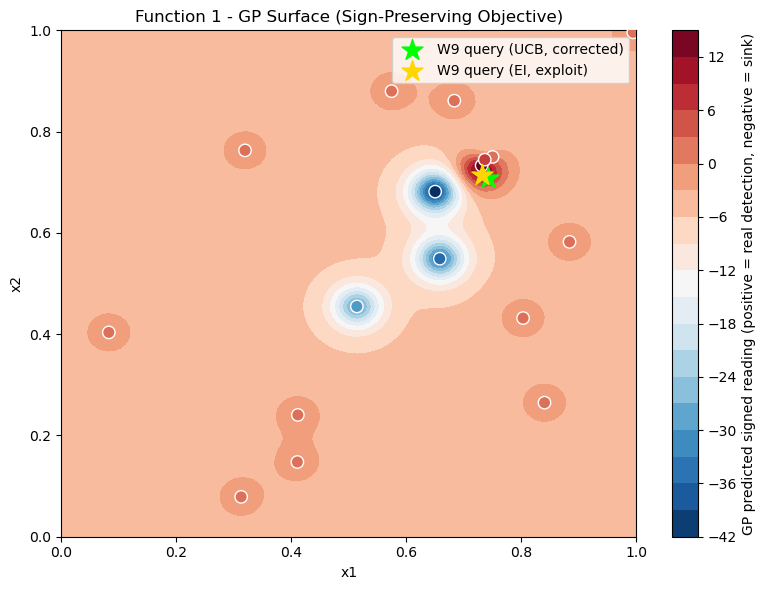

In [9]:
# Visualize the GP's predicted surface over a fine grid, overlaying the observed points 
# (colored by signed reading) and both candidate queries (UCB vs EI).

grid_n = 100
x1_grid = np.linspace(0, 1, grid_n)
x2_grid = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])

mu_grid, _ = gp_F1.predict(grid_points, return_std=True)
mu_grid = mu_grid.reshape(grid_n, grid_n)

plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, mu_grid, levels=20, cmap='RdBu_r')
plt.colorbar(label='GP predicted signed reading (positive = real detection, negative = sink)')
plt.scatter(all_inputs_F1[:, 0], all_inputs_F1[:, 1], c=signed_readings,
            edgecolors='white', s=80, cmap='RdBu_r', zorder=5)
plt.scatter(query_F1[0], query_F1[1], marker='*', c='lime', s=250, zorder=10, label='W9 query (UCB, corrected)')
plt.scatter(query_ei_F1[0], query_ei_F1[1], marker='*', c='gold', s=250, zorder=10, label='W9 query (EI, exploit)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Function 1 - GP Surface (Sign-Preserving Objective)')
plt.legend()
plt.tight_layout()
plt.show()


# Function 2, Noisy Log-Likelihood, 2D array, 10 original samples - Week 9

In [10]:
# =============================================================================
# FUNCTION 2 - Noisy Log-Likelihood (2D)
# =============================================================================
# Previous weeks
# W3: Same GP + EI + distance-maximisation pipeline as F1.
# W4: GP (Matérn + WhiteKernel noise) + Thompson sampling
# W5: Random Forest regression; greedy argmax of predicted mean over 50,000 random candidates
# W6: Random Forest (500 trees, depth 3); Thompson sampling (per-tree)
# W7: Random Forest: Max depth = 3; UCB κ = 1.5; full-ensemble UCB, improving uncertainty estimation
# W8: Anisotropic GP (PDP-derived length-scale bounds from RF) + UCB (κ = 0.1)

# change: Adapt kernel length scales via RF partial dependence 
#         to steer queries toward gathering new information rather than re-evaluating known optima.

print("\n" + "=" * 60)
print("Function 2 - Week 9")
print("=" * 60)

f2_inputs = np.load('initial_data/function_2/initial_inputs.npy')
f2_outputs = np.load('initial_data/function_2/initial_outputs.npy')

prev_queries_2 = np.array([
    [1.053349, 0.934354],               # W2
    [0.660188, 0.32993],                # W3
    [0.729589, 0.938148],               # W4
    [0.685444, 0.332456],               # W5 (so far the best)
    [0.684233, 0.440152],               # W6
    [0.692436, 0.991256],               # W7
    [0.700034, 0.148684],               # W8
])
prev_outputs_2 = np.array([-0.040652,          # W2 (worst result)
                           0.468742,           # W3 (fail)
                           0.487563,           # W4 (fail)
                           0.646548,           # W5 (above initial max)
                           0.578337,           # W6 (fail)
                           0.563546,           # W7 (fail)
                           0.683188,           # W8 (so far the best, above initial max))
                          ])

all_inputs_F2  = np.vstack([f2_inputs, prev_queries_2])
all_outputs_F2 = np.hstack([f2_outputs, prev_outputs_2])

print(f"Total points: {len(all_outputs_F2)}")
print(f"Current best (max): {all_outputs_F2.max():.3f}")


Function 2 - Week 9
Total points: 17
Current best (max): 0.683


In [11]:
rf_F2 = RandomForestRegressor(n_estimators=500, max_depth=3, min_samples_leaf=2, random_state=42)
rf_F2.fit(all_inputs_F2, all_outputs_F2)
print(f"Feature importances: x1={rf_F2.feature_importances_[0]:.3f}, x2={rf_F2.feature_importances_[1]:.3f}")

pd_x1 = partial_dependence(rf_F2, all_inputs_F2, features=[0], grid_resolution=100)
pd_x2 = partial_dependence(rf_F2, all_inputs_F2, features=[1], grid_resolution=100)

x1_grid_F2, x1_pd_F2 = pd_x1['grid_values'][0], pd_x1['average'][0]
x2_grid_F2, x2_pd_F2 = pd_x2['grid_values'][0], pd_x2['average'][0]

x1_pd_range = x1_pd_F2.max() - x1_pd_F2.min()
x2_pd_range = x2_pd_F2.max() - x2_pd_F2.min()

x1_active = x1_grid_F2[x1_pd_F2 >= x1_pd_F2.min() + 0.2 * x1_pd_range]
x2_active = x2_grid_F2[x2_pd_F2 >= x2_pd_F2.min() + 0.2 * x2_pd_range]

x1_input_span = x1_active.max() - x1_active.min() if len(x1_active) > 1 else 1.0
x2_input_span = x2_active.max() - x2_active.min() if len(x2_active) > 1 else 1.0

# Widen the upper bound a bit (x1.5) here# so the optimiser has room to settle away from the boundary.

x1_ls_upper = float(np.clip(x1_input_span, 0.1, 1.0)) * 1.5
x2_ls_upper = float(np.clip(x2_input_span, 0.1, 10.0)) * 1.5
x1_ls_lower = x1_ls_upper / 100
x2_ls_lower = x2_ls_upper / 100

print(f"\nPDP input spans: x1={x1_input_span:.3f}, x2={x2_input_span:.3f}")
print(f"Derived length-scale bounds (widened x1.5): x1=({x1_ls_lower:.4f}, {x1_ls_upper:.3f}), "
      f"x2=({x2_ls_lower:.4f}, {x2_ls_upper:.3f})")

Feature importances: x1=0.952, x2=0.048

PDP input spans: x1=0.476, x2=0.898
Derived length-scale bounds (widened x1.5): x1=(0.0071, 0.713), x2=(0.0135, 1.347)


In [12]:
# Fit a GP for Function 2 using per-dimension Matern length scales 
# (bounds set from earlier Random Forest-informed analysis) plus a White noise term.

kernel_F2 = (Matern(length_scale=[x1_ls_upper / 2, x2_ls_upper / 2],
                     length_scale_bounds=[(x1_ls_lower, x1_ls_upper),
                                          (x2_ls_lower, x2_ls_upper)],
                     nu=2.5)
             + WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-6, 1.0)))

gp_F2 = GaussianProcessRegressor(kernel=kernel_F2, n_restarts_optimizer=20, normalize_y=True)
gp_F2.fit(all_inputs_F2, all_outputs_F2)
print(f"Learned kernel: {gp_F2.kernel_}")

f_best_F2 = all_outputs_F2.max()

Learned kernel: Matern(length_scale=[0.0701, 1.35], nu=2.5) + WhiteKernel(noise_level=0.00895)


## Three candidate queries

1. **Exploit** — UCB with the original low kappa (0.2). Refines around the known best.
2. **Explore (EI)** — Expected Improvement relative to the current best. Balances "could beat
   the record" against "how uncertain are we."
3. **Explore (high kappa)** — UCB with kappa=2.0. Deliberately biased toward high-uncertainty
   regions, even at the cost of a lower predicted mean.

In [13]:
# Generate three candidate next queries over 50,000 random points using different
# acquisition strategies: (1) low-kappa UCB = exploit, (2) EI relative to the
# current best, (3) high-kappa UCB = explore. Print each candidate's stats.
np.random.seed(42)
candidates_F2 = np.random.uniform(0, 1, (50000, 2))
gp_mean, gp_std = gp_F2.predict(candidates_F2, return_std=True)

results = {}

kappa_exploit = 0.2
ucb_exploit = compute_ucb(gp_mean, gp_std, kappa=kappa_exploit)
idx = np.argmax(ucb_exploit)
results['exploit_ucb'] = (candidates_F2[idx], gp_mean[idx], gp_std[idx], ucb_exploit[idx])

ei_scores = compute_ei(gp_mean, gp_std, f_best_F2)
idx = np.argmax(ei_scores)
results['explore_ei'] = (candidates_F2[idx], gp_mean[idx], gp_std[idx], ei_scores[idx])

kappa_explore = 2.0
ucb_explore = compute_ucb(gp_mean, gp_std, kappa=kappa_explore)
idx = np.argmax(ucb_explore)
results['explore_ucb_highk'] = (candidates_F2[idx], gp_mean[idx], gp_std[idx], ucb_explore[idx])

for name, (pt, mu, sd, score) in results.items():
    print(f"\n[{name}]")
    print(f"  Query: {format_query(pt)}")
    print(f"  GP mean: {mu:.3f}   GP std: {sd:.3f}   score: {score:.3f}")


[exploit_ucb]
  Query: 0.701849-0.007270
  GP mean: 0.685   GP std: 0.043   score: 0.694

[explore_ei]
  Query: 0.709997-0.004026
  GP mean: 0.677   GP std: 0.054   score: 0.014

[explore_ucb_highk]
  Query: 0.728471-0.000053
  GP mean: 0.610   GP std: 0.097   score: 0.805


## Check the known blind spots explicitly

The gap between the low-x2 and high-x2 clusters (x1≈0.70, x2≈0.55–0.65), and the untested
low-x2 edge (x2≈0.00–0.02) at x1≈0.70–0.72, were flagged as the largest unexplored regions
inside the "good" x1 band. Score them directly rather than relying on random candidate sampling
to happen to land there.

In [14]:
# Directly score two manually identified 'blind spot' regions (an unexplored gap
# between clusters, and an untested low-x2 edge) rather than relying on random
# sampling to land there. Report GP mean/std, EI, UCB, and distance to the
# nearest existing sample for each.
gap_region  = np.array([[0.70, 0.60]])
edge_region = np.array([[0.715, 0.005]])

for name, pt in [('gap (x1~0.70, x2~0.60)', gap_region), ('low-x2 edge (x1~0.715, x2~0.005)', edge_region)]:
    mu, sd = gp_F2.predict(pt, return_std=True)
    print(f"{name}: mean={mu[0]:.3f}, std={sd[0]:.3f}, "
          f"EI={compute_ei(mu, sd, f_best_F2)[0]:.4f}, UCB(k=2)={compute_ucb(mu, sd, kappa=2.0)[0]:.3f}")

d_gap  = cdist(gap_region, all_inputs_F2).min()
d_edge = cdist(edge_region, all_inputs_F2).min()
print(f"\nDistance to nearest existing sample -> gap: {d_gap:.3f}, edge: {d_edge:.3f}")

gap (x1~0.70, x2~0.60): mean=0.635, std=0.038, EI=0.0010, UCB(k=2)=0.711
low-x2 edge (x1~0.715, x2~0.005): mean=0.665, std=0.064, EI=0.0137, UCB(k=2)=0.792

Distance to nearest existing sample -> gap: 0.161, edge: 0.129


In [15]:
# Pick the final Week 9 query for Function 2 from the candidate strategies
# computed above (here, the EI/explore strategy is chosen) and print it.
print("=" * 60)
print("Function 2 - Week 9")
print("=" * 60)

chosen_strategy = 'explore_ei'

query_F2, mean_F2, std_F2, score_F2 = results[chosen_strategy]

print(f"Chosen strategy: {chosen_strategy}")
print(f"Week 9 Query: {format_query(query_F2)}")
print(f"  GP mean:  {mean_F2:.3f}")
print(f"  GP std:   {std_F2:.3f}")
print(f"  Score:    {score_F2:.3f}")

Function 2 - Week 9
Chosen strategy: explore_ei
Week 9 Query: 0.709997-0.004026
  GP mean:  0.677
  GP std:   0.054
  Score:    0.014


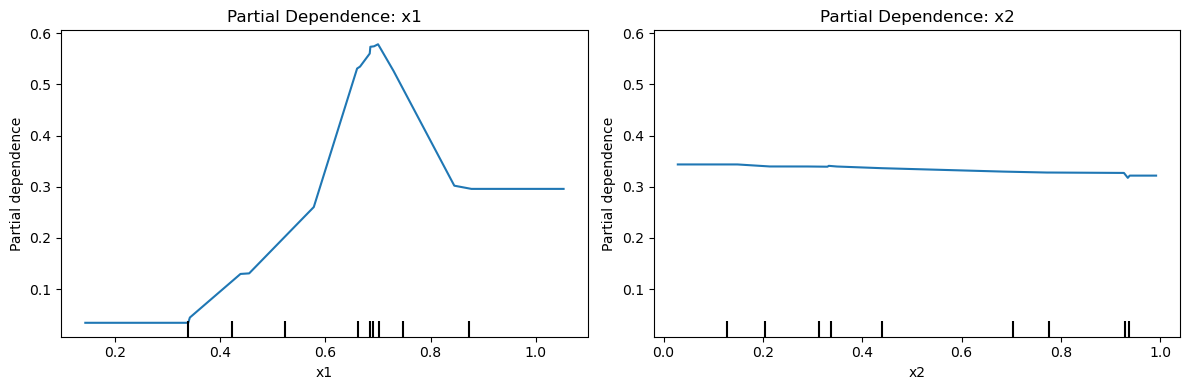

In [16]:
# Plot the Random Forest surrogate's partial dependence on x1 and x2 for Function 2.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
PartialDependenceDisplay.from_estimator(rf_F2, all_inputs_F2, features=[0, 1],
                                         feature_names=['x1', 'x2'], ax=axes)
axes[0].set_title('Partial Dependence: x1')
axes[1].set_title('Partial Dependence: x2')
plt.tight_layout()
plt.show()

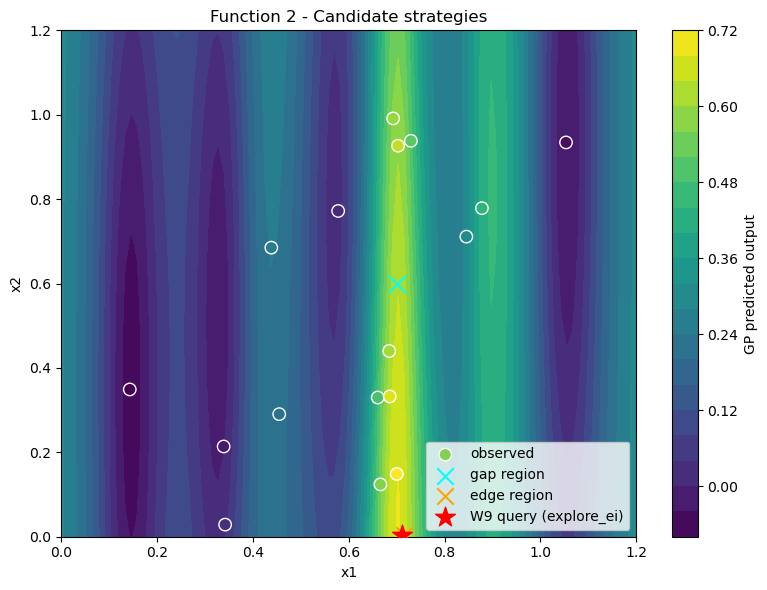

In [17]:
# Visualize the GP predicted surface for Function 2 over an extended grid,
# marking observed samples, the two blind-spot regions, and the chosen query.
grid_n = 100
x1_grid = np.linspace(0, 1.2, grid_n)
x2_grid = np.linspace(0, 1.2, grid_n)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])

mu_grid, _ = gp_F2.predict(grid_points, return_std=True)
mu_grid = mu_grid.reshape(grid_n, grid_n)

plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, mu_grid, levels=20, cmap='viridis')
plt.colorbar(label='GP predicted output')
plt.scatter(all_inputs_F2[:, 0], all_inputs_F2[:, 1], c=all_outputs_F2,
            edgecolors='white', s=80, cmap='viridis', zorder=5, label='observed')
plt.scatter(*gap_region[0], marker='x', c='cyan', s=140, zorder=9, label='gap region')
plt.scatter(*edge_region[0], marker='x', c='orange', s=140, zorder=9, label='edge region')
plt.scatter(query_F2[0], query_F2[1], marker='*', c='red', s=220, zorder=10, label=f'W9 query ({chosen_strategy})')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Function 2 - Candidate strategies')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Function 3, A drug discovery project, 3D array, 15 original samples - Week 9

In [18]:
# =============================================================================
# Function 3, A drug discovery project, 3D array, 15 original samples
# =============================================================================
# Previous weeks
# W3: Explicitly mixes exploration (random candidates), local exploitation (perturbations near the best point), 
#     and hypothesis-driven exploitation (directed candidates).
# W4: GP EI (ξ = 0.001, exploitation-biased) blended 50/50 with quadratic polynomial surrogate
# W5: Random Forest trained on degree-2 polynomial features; argmax over 10,000 global candidates
# W6: ExtraTrees (200 trees); Degree-2 polynomial interactions; Argmax over RF predictions
# W7: ExtraTrees + polynomial features; max_features: None vs. sqrt
# W8: ExtraTrees (WLS-weighted, polynomial features) + LCB (κ = 0.5) with exclusion filter

# change: Enforce space-filling distance constraints alongside polynomial feature interactions 
#         to prevent redundant evaluations in high-confidence areas.

print("\n" + "=" * 60)
print("Function 3 - Week 9")
print("=" * 60)

f3_inputs = np.load('initial_data/function_3/initial_inputs.npy')
f3_outputs = np.load('initial_data/function_3/initial_outputs.npy')

prev_queries_F3 = np.array([
    [0.540087, 0.652622, 0.079307],              # W2
    [0.378956, 0.302768, 0.459346],              # W3
    [0.375610, 0.057061, 0.589980],              # W4
    [0.378956, 0.302768, 0.459346],              # W5
    [0.378956, 0.302768, 0.459346],              # W6 (it was same as W5)
    [0.494932, 0.994690, 0.457121],              # W7
    [0.398479, 0.316913, 0.467387],              # W8
])
prev_outputs_F3 = np.array([
    -0.050615,               # W2 (fail)
    -0.019508,               # W3 (above initial max)
    -0.119425,               # W4  (fail)
    -0.021357,               # W5 (above initial max)
    -0.015072,               # W6 (above initial max, current best)
    -0.069598,               # W7 (fail)
    -0.023447,               # W7 (above initial max)
])

X = np.vstack([f3_inputs, prev_queries_F3])
Y = np.hstack([f3_outputs, prev_outputs_F3])

print(f"Total points: {len(Y)}, best (max): {Y.max():.6f}")


Function 3 - Week 9
Total points: 22, best (max): -0.015072


In [19]:
# Expand the raw 3D inputs (A, B, C) into second-degree polynomial and pairwise
# interaction features, to let a tree-based surrogate capture nonlinear effects.

poly   = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = ['A', 'B', 'C', 'A*B', 'A*C', 'B*C', 'A^2', 'B^2', 'C^2']

In [20]:
# Fit an ExtraTrees surrogate on the polynomial features and report its training
# R2 score plus feature importances (including the interaction terms).

rf_F3 = ExtraTreesRegressor(n_estimators=500, max_features='sqrt', min_samples_leaf=2, random_state=42)
rf_F3.fit(X_poly, Y)

train_preds = rf_F3.predict(X_poly)
print(f"RF train R2: {r2_score(Y, train_preds):.4f}")

print("\nRF feature importances:")
for name, imp in zip(feature_names, rf_F3.feature_importances_):
    print(f"  {name:6s}: {imp:.4f}")

RF train R2: 0.6778

RF feature importances:
  A     : 0.0752
  B     : 0.0595
  C     : 0.2389
  A*B   : 0.0552
  A*C   : 0.0542
  B*C   : 0.0288
  A^2   : 0.0503
  B^2   : 0.1470
  C^2   : 0.2908


In [21]:
# Print each point's ExtraTrees prediction next to its actual observed output,
# as a quick sanity check of surrogate fit quality.
train_preds = rf_F3.predict(X_poly)
print(f"\nRF train R2: {r2_score(Y, train_preds):.4f}")
print(f"RF train predictions vs actual:")
for pred, actual in zip(train_preds, Y):
    print(f"  predicted: {pred:.6f}, actual: {actual:.6f}")


RF train R2: 0.6778
RF train predictions vs actual:
  predicted: -0.100873, actual: -0.112122
  predicted: -0.090611, actual: -0.087963
  predicted: -0.101396, actual: -0.111415
  predicted: -0.061359, actual: -0.034835
  predicted: -0.072999, actual: -0.048008
  predicted: -0.091275, actual: -0.110621
  predicted: -0.219481, actual: -0.398926
  predicted: -0.174415, actual: -0.113869
  predicted: -0.106311, actual: -0.131461
  predicted: -0.095148, actual: -0.094190
  predicted: -0.067784, actual: -0.046947
  predicted: -0.089410, actual: -0.105965
  predicted: -0.143501, actual: -0.118048
  predicted: -0.058978, actual: -0.036378
  predicted: -0.084450, actual: -0.056758
  predicted: -0.058813, actual: -0.050615
  predicted: -0.033601, actual: -0.019508
  predicted: -0.091631, actual: -0.119425
  predicted: -0.033601, actual: -0.021357
  predicted: -0.033601, actual: -0.015072
  predicted: -0.077786, actual: -0.069598
  predicted: -0.039502, actual: -0.023447


In [22]:
np.random.seed(42)
candidates_F3 = np.random.uniform(0, 1, (50000, 3))

# widened exclusion radius: was 0.01, now 0.05
min_distance = 0.05
distances_F3 = np.min(np.linalg.norm(candidates_F3[:, None, :] - X[None, :, :], axis=2), axis=1)
candidates_F3 = candidates_F3[distances_F3 > min_distance]
print(f"Candidates remaining after exclusion filter: {len(candidates_F3)}")

cand_poly = poly.transform(candidates_F3)

Candidates remaining after exclusion filter: 49505


In [23]:
# Get per-tree mean/std (mu, sigma) predictions from the ExtraTrees ensemble for
# all candidates, score them with both UCB and EI, and print the top-10 candidates
# under each acquisition function for comparison.

mu, sigma = rf_mu_sigma(rf_F3, cand_poly)

ucb_scores = compute_ucb(mu, sigma, kappa=2.5)
ei_scores  = compute_ei(mu, sigma, f_best, xi=0.01)

best_idx_ucb = np.argmax(ucb_scores)
best_idx_ei  = np.argmax(ei_scores)

query_ucb = candidates_F3[best_idx_ucb]
query_ei  = candidates_F3[best_idx_ei]

top_n = 10
print(f"\nTop {top_n} candidates by UCB (kappa=2.5):")
top_ucb = np.argsort(ucb_scores)[::-1][:top_n]
for i, idx in enumerate(top_ucb):
    print(f"  {i+1}: {format_query(candidates_F3[idx])}  mu={mu[idx]:.6f}  sigma={sigma[idx]:.6f}  UCB={ucb_scores[idx]:.6f}")

print(f"\nTop {top_n} candidates by EI (xi=0.01):")
top_ei = np.argsort(ei_scores)[::-1][:top_n]
for i, idx in enumerate(top_ei):
    print(f"  {i+1}: {format_query(candidates_F3[idx])}  mu={mu[idx]:.6f}  sigma={sigma[idx]:.6f}  EI={ei_scores[idx]:.6f}")


Top 10 candidates by UCB (kappa=2.5):
  1: 0.302950-0.370366-0.629419  mu=-0.094925  sigma=0.071064  UCB=0.082736
  2: 0.313351-0.359529-0.644244  mu=-0.095774  sigma=0.071311  UCB=0.082504
  3: 0.295126-0.361138-0.622693  mu=-0.094449  sigma=0.070614  UCB=0.082087
  4: 0.296887-0.307921-0.645401  mu=-0.091639  sigma=0.069396  UCB=0.081851
  5: 0.304335-0.310058-0.639855  mu=-0.089092  sigma=0.068321  UCB=0.081711
  6: 0.315293-0.348730-0.648146  mu=-0.095543  sigma=0.070867  UCB=0.081625
  7: 0.331148-0.341148-0.645924  mu=-0.092470  sigma=0.069636  UCB=0.081620
  8: 0.289179-0.318847-0.696948  mu=-0.104595  sigma=0.074468  UCB=0.081575
  9: 0.310719-0.369429-0.597625  mu=-0.087633  sigma=0.067620  UCB=0.081416
  10: 0.312121-0.297673-0.657578  mu=-0.092323  sigma=0.069489  UCB=0.081400

Top 10 candidates by EI (xi=0.01):
  1: 0.196115-0.232094-0.380496  mu=-0.074421  sigma=0.030606  EI=0.000000
  2: 0.581878-0.070483-0.713192  mu=-0.109285  sigma=0.049684  EI=0.000000
  3: 0.776714-

In [24]:
# Report the final chosen query (UCB) and the alternative not chosen (EI) for
# Function 3, along with each candidate's distance to the nearest existing sample.

print("=" * 60)
print("Function 3 - Week 9")
print("=" * 60)

print(f"\nRecommended Query (UCB - sumbission): {format_query(query_ucb)}")
print(f"  mu={mu[best_idx_ucb]:.6f}, sigma={sigma[best_idx_ucb]:.6f}, UCB={ucb_scores[best_idx_ucb]:.6f}")

print(f"\nRecommended Query (EI- not choose):  {format_query(query_ei)}")
print(f"  mu={mu[best_idx_ei]:.6f}, sigma={sigma[best_idx_ei]:.6f}, EI={ei_scores[best_idx_ei]:.6f}")

for name, q in [('UCB', query_ucb), ('EI', query_ei)]:
    d = np.linalg.norm(X - q, axis=1)
    print(f"\nNearest existing point to {name} candidate: dist={d.min():.6f} (point {X[np.argmin(d)]})")

Function 3 - Week 9

Recommended Query (UCB - sumbission): 0.302950-0.370366-0.629419
  mu=-0.094925, sigma=0.071064, UCB=0.082736

Recommended Query (EI- not choose):  0.374540-0.950714-0.731994
  mu=-0.115003, sigma=0.062900, EI=0.000000

Nearest existing point to UCB candidate: dist=0.195544 (point [0.398479 0.316913 0.467387])

Nearest existing point to EI candidate: dist=0.303287 (point [0.494932 0.99469  0.457121])


## Choice between the UCB and EI candidate

- **UCB candidate**: much higher sigma (more uncertain region, further from all known data — a genuine exploration move). Good choice if several weeks of budget left and want to map unexplored territory.
- **EI candidate**: closer to the current best region but pushed just outside the exhausted cluster, balancing a real chance of beating the current record with less risk. Good choice for a safer, more exploitation-leaning step while still avoiding the near-duplicate problem.
- Either one is a better next step, since both explicitly account for model uncertainty and neither is a near-duplicate of an already (repeatedly) sampled point.

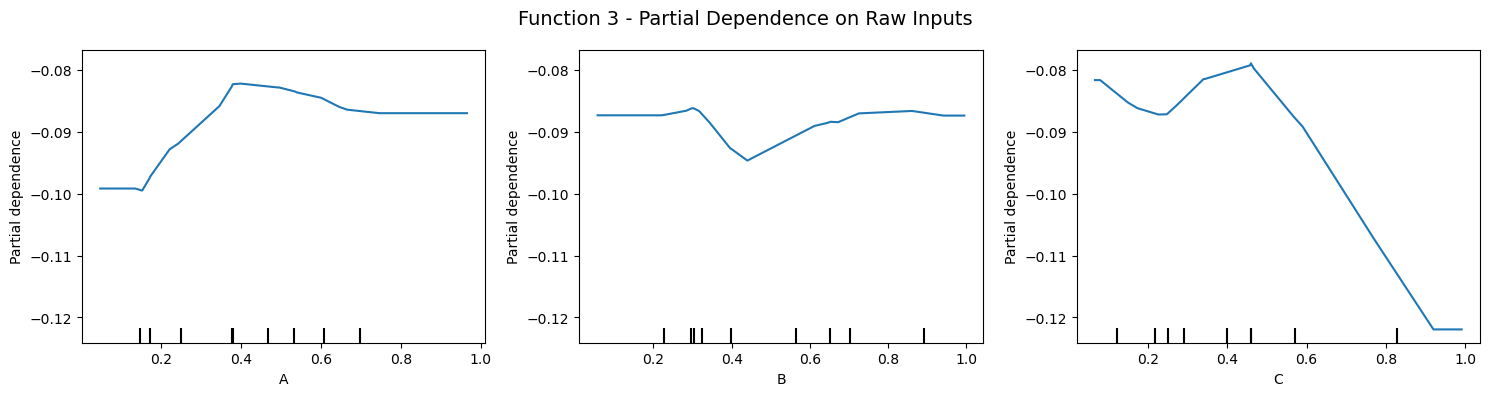

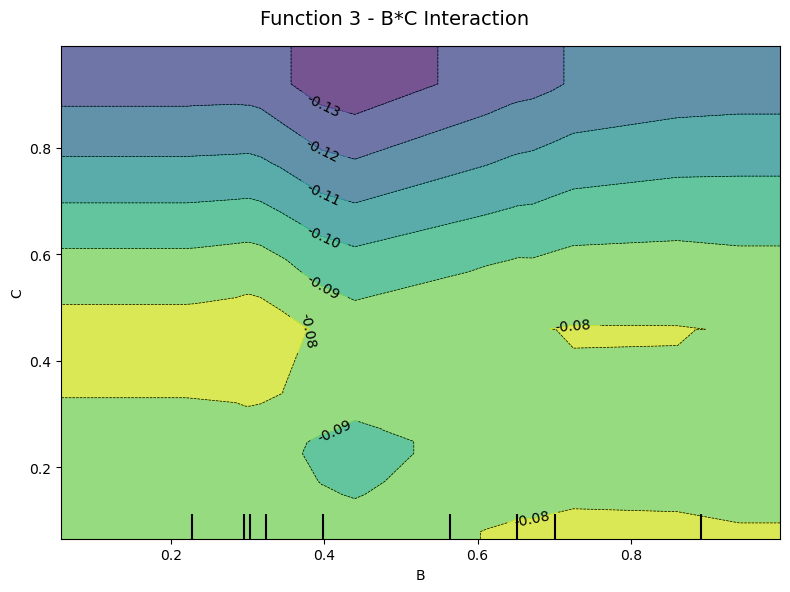

In [25]:
# Refit ExtraTrees directly on the raw (non-polynomial) inputs, 
# then plot partial dependence for each feature and for the B*C interaction, 
# to visually confirm the interaction effect found via feature importances.

rf_raw = ExtraTreesRegressor(n_estimators=500, max_features='sqrt', min_samples_leaf=2, random_state=42)
rf_raw.fit(X, Y)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(rf_raw, X, features=[0, 1, 2],
                                         feature_names=['A', 'B', 'C'], ax=axes)
plt.suptitle('Function 3 - Partial Dependence on Raw Inputs', fontsize=14)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(rf_raw, X, features=[(1, 2)],
                                         feature_names=['A', 'B', 'C'], ax=[ax2])
plt.suptitle('Function 3 - B*C Interaction', fontsize=14)
plt.tight_layout()
plt.show()

# Function 4, Warehouse business, 4D array, 30 original samples - Week 9

In [26]:
# =============================================================================
# Function 4, Warehouse business, 4D array, 30 original samples
# =============================================================================
# Previous weeks
# W3: Exploration-oriented due to relatively high (UCB, κ = 2.0) over 10k uniformly random candidates.
# W4: GP (Matérn) + Thompson sampling
# W5: RF surrogate; uncertainty estimated from tree-to-tree disagreement (rf_predict_with_std); 
#     acquisition = EI (ξ = 0.01) over Latin Hypercube candidates
# W6: SVM classifier (gate) + ARD GP (refine); Threshold-based binary labelling; EI
# W7: SVM gate + GP (EI); SVM probability threshold; Increased GP α to smooth noisy responses and added global; added global LHS
# W8: GP (Matérn, selected over RF using LOO R²) + UCB (κ = 0.5)

# change: Incorporate extensive human diagnostic checks on response surfaces 
#         to prevent high uncertainty from overriding poor predicted means in candidate selection.

print("\n" + "=" * 60)
print("Function 4 - Week 9")
print("=" * 60)

f4_inputs  = np.load('initial_data/function_4/initial_inputs.npy')
f4_outputs = np.load('initial_data/function_4/initial_outputs.npy')

prev_queries_F4 = np.array([
    [0.149845, 0.155724, 0.461280, 0.344491],              # W2
    [0.330258, 0.414348, 0.433728, 0.411341],              # W3
    [0.424125, 0.404716, 0.487507, 0.367688],              # W4
    [0.424125, 0.404716, 0.487507, 0.367688],              # W5 so it was the same as Week 4
    [0.255396, 0.450674, 0.468413, 0.490566],              # W6
    [0.371614, 0.422247, 0.370132, 0.421911],              # W7 
    [0.378911, 0.420065, 0.360647, 0.355610],              # W8
])
prev_outputs_F4 = np.array([-7.13212,          # W2 fail
                            0.20379,           # W3 (above initial max)
                            -0.99160,          # W4 (above initial max)
                            -0.99147,          # W5 (above initial max)
                            -3.142015,         # W6 (above initial max)
                            0.657358,          # W7 (above initial max, second best)
                            0.664078,         # W8 (above initial max, so far the best)
                           ]) 

all_inputs_F4  = np.vstack([f4_inputs, prev_queries_F4])
all_outputs_F4 = np.hstack([f4_outputs, prev_outputs_F4])

best_idx = np.argmax(all_outputs_F4)
best_point_so_far = all_inputs_F4[best_idx]
best_val_so_far = all_outputs_F4[best_idx]
print(f"Total points: {len(all_outputs_F4)}, best (max) so far: "
      f"{best_val_so_far:.4f} at {format_query(best_point_so_far)}")


Function 4 - Week 9
Total points: 37, best (max) so far: 0.6641 at 0.378911-0.420065-0.360647-0.355610


In [27]:
# Build a candidate pool for Function 4 by perturbing three previous weeks' queries (W3, W7, W8) 
# with different Gaussian noise scales, focusing the search near regions
# that have historically performed well.

np.random.seed(42)

week3_query = prev_queries_F4[1]
week7_query = prev_queries_F4[5]
week8_query = prev_queries_F4[6]

candidates_w3 = np.array([np.clip(week3_query + np.random.normal(0, 0.05, 4), 0, 1) for _ in range(3000)])
candidates_w7 = np.array([np.clip(week7_query + np.random.normal(0, 0.05, 4), 0, 1) for _ in range(2000)])
candidates_w8 = np.array([np.clip(week8_query + np.random.normal(0, 0.03, 4), 0, 1) for _ in range(5000)])
candidates_w8_tight = np.array([np.clip(week8_query + np.random.normal(0, 0.015, 4), 0, 1) for _ in range(3000)])

candidates_F4 = np.vstack([candidates_w3, candidates_w7, candidates_w8, candidates_w8_tight])
print(f"Candidates: {len(candidates_F4)} total "
      f"({len(candidates_w3)} W3 + {len(candidates_w7)} W7 + {len(candidates_w8)} W8 "
      f"+ {len(candidates_w8_tight)} W8-tight)")

Candidates: 13000 total (3000 W3 + 2000 W7 + 5000 W8 + 3000 W8-tight)


In [28]:
# Refit a GP for Function 4 with per-dimension Matern length scales 
# (x3's bound loosened), then predict mean/std/UCB over the candidate pool.

kernel_F4 = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
    length_scale=[0.3, 0.3, 0.2, 0.3],
    length_scale_bounds=[(0.1, 2.0), (0.1, 2.0), (0.1, 1.0), (0.1, 2.0)],  # x3 bound loosened
    nu=2.5,
)
gp_F4 = GaussianProcessRegressor(kernel=kernel_F4, n_restarts_optimizer=20, alpha=0.01, normalize_y=True)
gp_F4.fit(all_inputs_F4, all_outputs_F4)
print(f"\nRefit kernel: {gp_F4.kernel_}")

mu_F4, sigma_F4 = gp_F4.predict(candidates_F4, return_std=True)
kappa_F4 = 1.0
ucb_F4 = compute_ucb(mu_F4, sigma_F4, kappa_F4)



Refit kernel: 1.75**2 * Matern(length_scale=[1.13, 1.06, 1, 1.07], nu=2.5)


In [29]:
# Report Option A: the candidate with the highest UCB score (exploration-leaning pick).

ucb_best_idx = np.argmax(ucb_F4)
ucb_query = candidates_F4[ucb_best_idx]

print("\n--- Option A: UCB pick (exploration-leaning) ---")
print(f"Query: {format_query(ucb_query)}")
print(f"mean: {mu_F4[ucb_best_idx]:.3f}")
print(f"std:  {sigma_F4[ucb_best_idx]:.3f}")
print(f"UCB:  {ucb_F4[ucb_best_idx]:.6f}")


--- Option A: UCB pick (exploration-leaning) ---
Query: 0.416714-0.400385-0.334493-0.422238
mean: 0.246
std:  0.713
UCB:  0.959691


In [30]:
# Report Option B: among candidates with below-median predicted uncertainty,
# pick the one with the highest predicted mean (exploitation-leaning pick).

sigma_median = np.median(sigma_F4)
confident_mask = sigma_F4 <= sigma_median
confident_idx = np.where(confident_mask)[0]
exploit_best_local = confident_idx[np.argmax(mu_F4[confident_idx])]
exploit_query = candidates_F4[exploit_best_local]

print("\n--- Option B: exploitation-leaning pick (highest mean, sigma <= median) ---")
print(f"Query: {format_query(exploit_query)}")
print(f"mean: {mu_F4[exploit_best_local]:.3f}")
print(f"std:  {sigma_F4[exploit_best_local]:.3f}")
print(f"UCB:  {ucb_F4[exploit_best_local]:.6f}")



--- Option B: exploitation-leaning pick (highest mean, sigma <= median) ---
Query: 0.409891-0.415315-0.374280-0.408847
mean: 0.350
std:  0.526
UCB:  0.876882


In [31]:
# Print a summary comparing the current best observed value against 
# Option A (UCB/exploratory) and Option B (exploit-leaning), to support a final choice.

print("=" * 60)
print("Function 4 - Week 9 Summary")
print("=" * 60)

print(f"Current best observed (W8):     {best_val_so_far:.4f} at {format_query(best_point_so_far)}")
print(f"Option A (UCB, exploratory):    predicted mean {mu_F4[ucb_best_idx]:.3f}, "
      f"std {sigma_F4[ucb_best_idx]:.3f} -> {format_query(ucb_query)}")
print(f"Option B (exploit-leaning):     predicted mean {mu_F4[exploit_best_local]:.3f}, "
      f"std {sigma_F4[exploit_best_local]:.3f} -> {format_query(exploit_query)}")
print("\nNote: neither option's GP mean exceeds the current best observed value (0.664).")
print("Option A bets on a highly uncertain region; Option B stays closer to what has")
print("Now it is worked (W8) with tighter uncertainty. To pick based on risk tolerance")

Function 4 - Week 9 Summary
Current best observed (W8):     0.6641 at 0.378911-0.420065-0.360647-0.355610
Option A (UCB, exploratory):    predicted mean 0.246, std 0.713 -> 0.416714-0.400385-0.334493-0.422238
Option B (exploit-leaning):     predicted mean 0.350, std 0.526 -> 0.409891-0.415315-0.374280-0.408847

Note: neither option's GP mean exceeds the current best observed value (0.664).
Option A bets on a highly uncertain region; Option B stays closer to what has
Now it is worked (W8) with tighter uncertainty. To pick based on risk tolerance


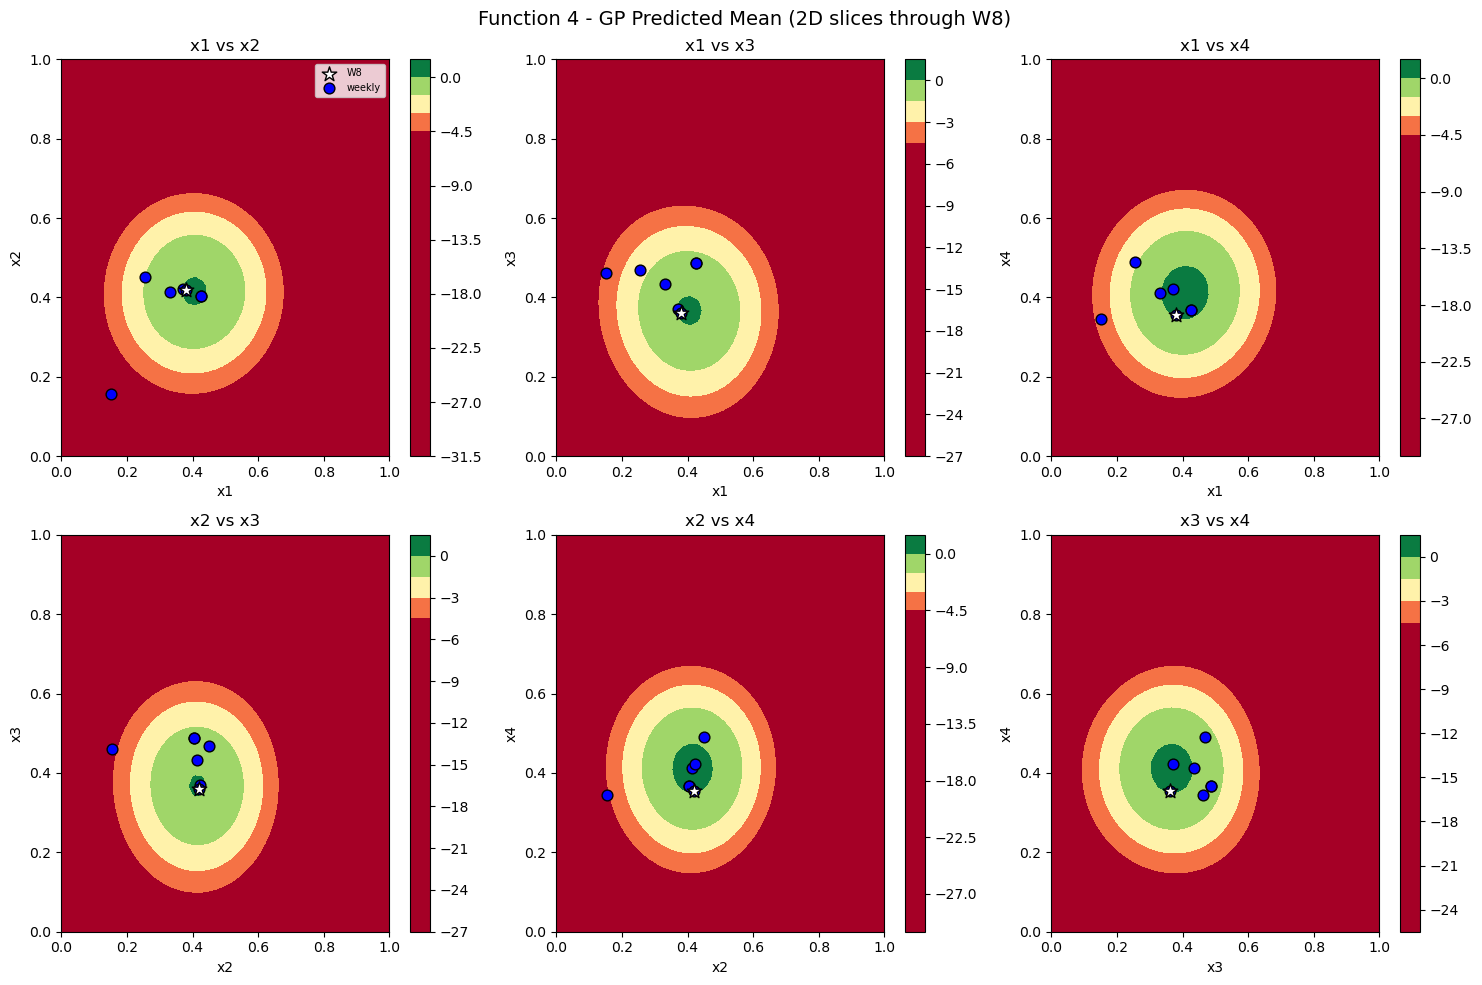

In [32]:

dim_names = ['x1', 'x2', 'x3', 'x4']
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (d1, d2) in enumerate(pairs):
    ax = axes[idx]
    res = 50
    v1 = np.linspace(0, 1, res)
    v2 = np.linspace(0, 1, res)
    grid = np.tile(week8_query, (res * res, 1))
    g1, g2 = np.meshgrid(v1, v2)
    grid[:, d1] = g1.ravel()
    grid[:, d2] = g2.ravel()

    pred = gp_F4.predict(grid).reshape(res, res)
    contour = ax.contourf(v1, v2, pred, levels=20, cmap='RdYlGn', vmin=-5, vmax=1)
    plt.colorbar(contour, ax=ax)

    # plot W8 (so far the best) and other queries
    ax.scatter(week8_query[d1], week8_query[d2], c='white', edgecolors='black', marker='*', s=120, zorder=5, label='W8')
    ax.scatter(prev_queries_F4[:, d1], prev_queries_F4[:, d2], c='blue', edgecolors='black', s=60, zorder=4, label='weekly')

    ax.set_xlabel(dim_names[d1])
    ax.set_ylabel(dim_names[d2])
    ax.set_title(f'{dim_names[d1]} vs {dim_names[d2]}')

axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - GP Predicted Mean (2D slices through W8)', fontsize=14)
plt.tight_layout()
plt.show()

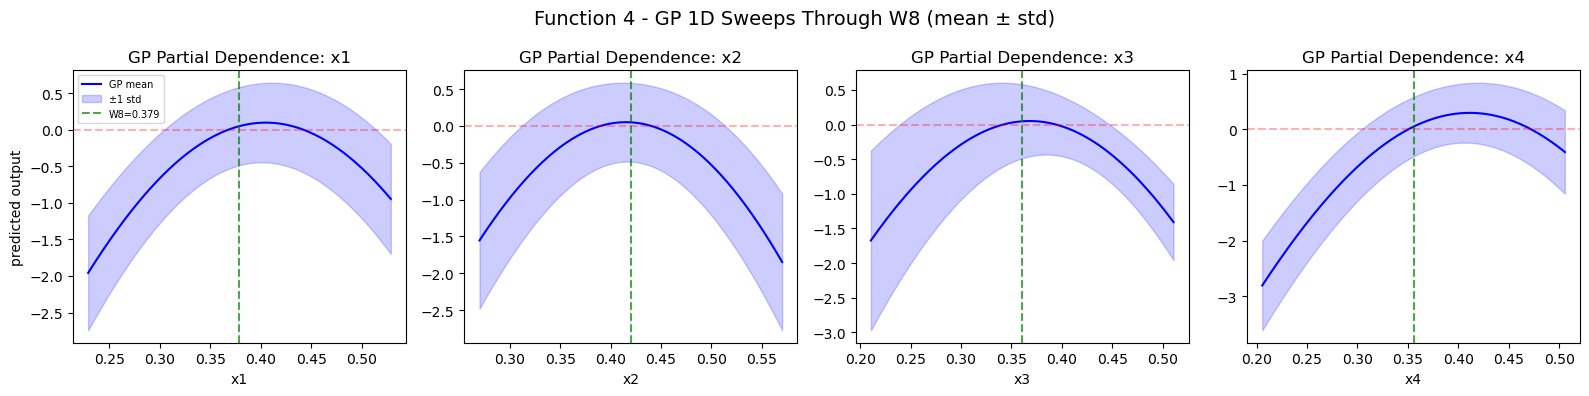

In [33]:
# For each input dimension, sweep its value in a window around the W8 query 
# while holding the other dimensions fixed, and plot the GP's predicted mean +/- std 
# to visualize the model's 1D sensitivity along each axis.

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    sweep = np.linspace(week8_query[i] - 0.15, week8_query[i] + 0.15, 200)    
    test_points = np.tile(week8_query, (200, 1))
    test_points[:, i] = sweep

    sweep_mu, sweep_std = gp_F4.predict(test_points, return_std=True)

    ax.plot(sweep, sweep_mu, 'b-', label='GP mean')
    ax.fill_between(sweep, sweep_mu - sweep_std, sweep_mu + sweep_std, alpha=0.2, color='blue', label='±1 std')
    ax.axvline(x=week8_query[i], color='green', linestyle='--', alpha=0.7, label=f'W8={week8_query[i]:.3f}')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    ax.set_xlabel(dim_names[i])
    ax.set_ylabel('predicted output' if i == 0 else '')
    ax.set_title(f'GP Partial Dependence: {dim_names[i]}')
axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - GP 1D Sweeps Through W8 (mean ± std)', fontsize=14)
plt.tight_layout()
plt.show()

# Function 5, A chemical process in a factory, 4D array, 20 original samples - Week 9

In [34]:
# =============================================================================
# Function 5, A chemical process in a factory, 4D array, 20 original samples
# =============================================================================
# Previous weeks
# W3: Strong exploitation
#     SVR ranks a locally generated candidate pool (local perturbations and directional moves around the incumbent). 
# W4: Linear regression (search direction) → SVR pre-filter → GP EI (ξ = 0.005)
# W5: Two-stage approach: SVR pre-filters candidates (top 3,000 retained), 
#     then GP (log-transformed outputs, Matérn kernel) evaluates them using EI (ξ = 0.005)
# W6: SVR + GP (log space); Log transform of output; EI
# W7: SVR filter + GP (EI); SVR candidate pool = 3000; EI ξ = 0.005; improving search coverage
# W8: SVR pre-filter (top 3000 candidates) → GP (log-transformed outputs) + EI (ξ = 0.005)

# change: Use a lightweight SVR pre-filter to narrow candidate pools before running GP optimisation, 
#         reduce overall computational overhead
 
print("\n" + "=" * 60)
print("Function 5 - Week 9")
print("=" * 60)

f5_inputs  = np.load('initial_data/function_5/initial_inputs.npy')
f5_outputs = np.load('initial_data/function_5/initial_outputs.npy')

prev_queries_F5 = np.array([
    [0.417098, 0.756030, 0.129487, 1.149173],               # W2
    [0.386633, 0.821843, 0.127990, 0.999900],               # W3
    [0.269378, 0.810637, 0.999999, 0.999999],               # W4
    [0.366671, 0.879874, 0.999999, 0.996800],               # W5
    [0.495228, 0.809693, 0.999999, 0.999990],               # W6
    [0.382122, 0.995456, 0.999999, 0.999999],               # W7 (second best)
    [0.566703, 0.999727, 0.999999, 0.999999],               # W8 (best)
])
prev_outputs_F5 = np.array([1829.809875,                    # W2 (above initial max)
                            710.602251,                     # W3 (fail)
                            2699.104490,                    # W4 (above initial max)
                            3179.389393,                    # W5 (above initial max)
                            2855.140103,                    # W6 (above initial max)
                            4461.243621,                    # W7 (above initial max)
                            4826.282687,                    # W8 (above initial max,)
                           ])

all_inputs_F5  = np.vstack([f5_inputs, prev_queries_F5])
all_outputs_F5 = np.hstack([f5_outputs, prev_outputs_F5])

print(f"Total points: {len(all_outputs_F5)}, best (max): {all_outputs_F5.max():.2f}")


Function 5 - Week 9
Total points: 27, best (max): 4826.28


In [35]:
# Standardize inputs and outputs, then fit an SVR (RBF kernel) surrogate for
# Function 5 as an alternative model to compare against the GP.

input_scaler  = StandardScaler()
output_scaler = StandardScaler()
X_scaled = input_scaler.fit_transform(all_inputs_F5)
Y_scaled = output_scaler.fit_transform(all_outputs_F5.reshape(-1, 1)).ravel()
 
svr_F5 = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.01)
svr_F5.fit(X_scaled, Y_scaled)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,100
,epsilon,0.01
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [36]:
# Fit a GP (Matern kernel) on log1p-transformed outputs for Function 5,
#  to stabilise variance across the observed output range.

y_log     = np.log1p(all_outputs_F5)
kernel_gp = ConstantKernel(1.0, (0.001, 1000)) * Matern(length_scale=0.2, nu=2.5)
gp_F5     = GaussianProcessRegressor(kernel=kernel_gp, n_restarts_optimizer=25, normalize_y=True)
gp_F5.fit(all_inputs_F5, y_log)

,kernel,"1**2 * Matern...e=0.2, nu=2.5)"
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,25
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,"Matern(length...e=0.2, nu=2.5)"
,kernel__k1__constant_value,1.0


In [37]:
# Build two candidate sets around the current best point for Function 5:
# (1) 'local' - small isotropic perturbations with x3/x4 pinned near their upper bound, 
# and (2) 'directed' - perturbations that specifically push x1 upward,
# based on prior sensitivity findings. Combine both into one candidate pool.

best_point = all_inputs_F5[np.argmax(all_outputs_F5)]
np.random.seed(42)
 
local = []
for _ in range(6000):
    c    = best_point + np.random.normal(0, 0.03, 4)
    c    = np.clip(c, 0, 1)
    c[2] = 0.999999  # x3 pinned
    c[3] = 0.999999  # x4 pinned
    local.append(c)
 
directed = []
for _ in range(4000):
    c    = best_point.copy()
    c[0] = np.clip(c[0] + abs(np.random.normal(0, 0.05)), 0, 1)  # x1 up
    c[1] = np.clip(c[1] + np.random.normal(0, 0.03), 0, 1)        # x2 symmetric
    c[2] = 0.999999
    c[3] = 0.999999
    directed.append(c)
 
candidates_F5 = np.vstack([local, directed])

In [38]:
print("=" * 60)
print("Function 5 - Week 9")
print("=" * 60)

# SVR pre-filter: top 3000
X_cand_scaled = input_scaler.transform(candidates_F5)
svr_preds_s   = svr_F5.predict(X_cand_scaled)
svr_preds     = output_scaler.inverse_transform(svr_preds_s.reshape(-1, 1)).ravel()
 
top_idx  = np.argsort(svr_preds)[-5000:]
filtered = candidates_F5[top_idx]
 
mu_log, sigma_log = gp_F5.predict(filtered, return_std=True)
ei_F5             = compute_ei(mu_log, sigma_log, np.log1p(all_outputs_F5.max()), xi=0.01)
 
best_idx_F5 = np.argmax(ei_F5)
query_F5    = filtered[best_idx_F5]
 
print(f"\nWeek 9 Query:       {format_query(query_F5)}")
print(f"GP predicted yield: {np.expm1(mu_log[best_idx_F5]):.2f}")
print(f"GP std (log scale): {sigma_log[best_idx_F5]:.4f}")
print(f"SVR prediction:     {svr_preds[top_idx[best_idx_F5]]:.2f}")
print(f"EI:                 {ei_F5[best_idx_F5]:.6f}")

Function 5 - Week 9

Week 9 Query:       0.629172-0.999999-0.999999-0.999999
GP predicted yield: 4699.22
GP std (log scale): 0.1350
SVR prediction:     4789.53
EI:                 0.037494


In [39]:
# Compare GP vs SVR predictions against the actual outputs at all historical queries, 
# then sweep x1 across a range of values (other inputs fixed) 
# to check both models' sensitivity/agreement along that dimension.

print("\n--- GP vs SVR at historical queries ---")
print(f"{'Week':<6} {'Actual':>10} {'GP pred':>10} {'SVR pred':>10}")
for i, (q, actual) in enumerate(zip(prev_queries_F5, prev_outputs_F5)):
    gp_pred  = np.expm1(gp_F5.predict(q.reshape(1, -1))[0])
    svr_pred = output_scaler.inverse_transform(
        svr_F5.predict(input_scaler.transform(q.reshape(1, -1))).reshape(-1, 1)
    ).ravel()[0]
    print(f"W{i+1:<5} {actual:>10.1f} {gp_pred:>10.1f} {svr_pred:>10.1f}")
 

print("\n--- x1 sensitivity check ---")
print(f"{'x1':>6} {'GP yield':>10} {'SVR yield':>10}")
for x1_val in [0.40, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
    test_point = np.array([[x1_val, 0.999999, 0.999999, 0.999999]])
    gp_pred = np.expm1(gp_F5.predict(test_point)[0])
    svr_pred = output_scaler.inverse_transform(
        svr_F5.predict(input_scaler.transform(test_point)).reshape(-1, 1)
    ).ravel()[0]
    print(f"{x1_val:>6.2f} {gp_pred:>10.1f} {svr_pred:>10.1f}")


--- GP vs SVR at historical queries ---
Week       Actual    GP pred   SVR pred
W1         1829.8     1829.8     1816.4
W2          710.6      710.6      725.1
W3         2699.1     2699.1     2684.4
W4         3179.4     3179.4     3193.4
W5         2855.1     2855.1     2840.5
W6         4461.2     4461.2     4446.7
W7         4826.3     4826.3     4840.3

--- x1 sensitivity check ---
    x1   GP yield  SVR yield
  0.40     4567.1     4542.8
  0.50     4802.8     4778.1
  0.55     4837.3     4837.0
  0.60     4780.2     4829.8
  0.65     4620.0     4743.6
  0.70     4363.4     4575.9
  0.75     4030.9     4335.0
  0.80     3649.9     4038.9


In [40]:
# Same sensitivity check as above, but sweeping x2 instead of x1.

print("\n--- x2 sensitivity check ---")
print(f"{'x2':>6} {'GP yield':>10} {'SVR yield':>10}")
for x2_val in [0.85, 0.90, 0.92, 0.95, 0.97, 0.99, 1.00]:
    test_point = np.array([[best_point[0], x2_val, 0.999999, 0.999999]])
    gp_pred = np.expm1(gp_F5.predict(test_point)[0])
    svr_pred = output_scaler.inverse_transform(
        svr_F5.predict(input_scaler.transform(test_point)).reshape(-1, 1)
    ).ravel()[0]
    print(f"{x2_val:>6.2f} {gp_pred:>10.1f} {svr_pred:>10.1f}")


--- x2 sensitivity check ---
    x2   GP yield  SVR yield
  0.85     3253.3     3440.2
  0.90     3728.6     3908.9
  0.92     3936.9     4099.1
  0.95     4264.5     4383.3
  0.97     4489.6     4570.1
  0.99     4716.4     4753.1
  1.00     4829.4     4842.8


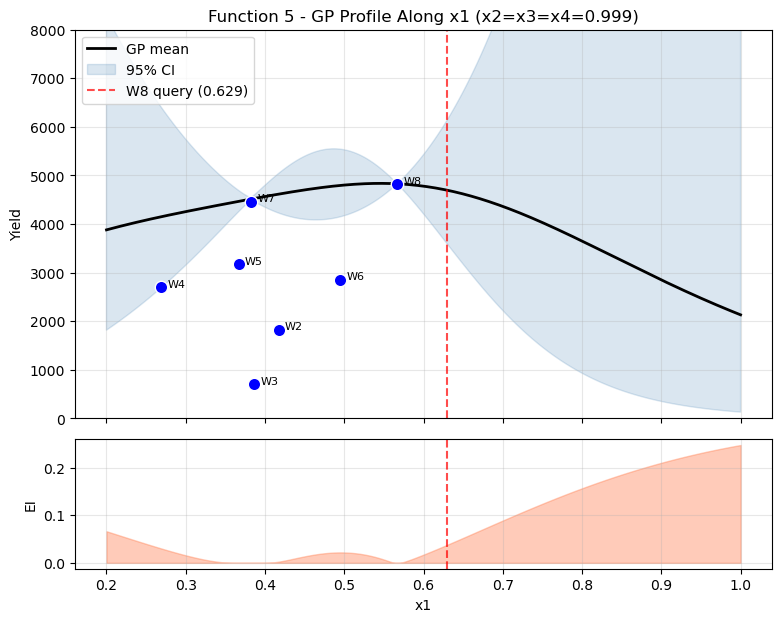

In [41]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7),
                                sharex=True, gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})

x1_sweep = np.linspace(0.2, 1.0, 500)
sweep_4d = np.column_stack([x1_sweep,
                            np.full(500, 0.999999),
                            np.full(500, 0.999999),
                            np.full(500, 0.999999)])

mu_sweep, sigma_sweep = gp_F5.predict(sweep_4d, return_std=True)
yield_mean = np.expm1(mu_sweep)
yield_upper = np.expm1(mu_sweep + 1.96 * sigma_sweep)
yield_lower = np.expm1(mu_sweep - 1.96 * sigma_sweep)

# top panel: GP mean + uncertainty
ax1.plot(x1_sweep, yield_mean, 'k-', linewidth=2, label='GP mean')
ax1.fill_between(x1_sweep, yield_lower, yield_upper, alpha=0.2, color='steelblue',
                 label='95% CI')

# overlay query history ----- f'W{i+2} because of no query for week 1
for i in range(len(prev_queries_F5)):
    ax1.scatter(prev_queries_F5[i, 0], prev_outputs_F5[i], c='blue',
                edgecolors='white', s=80, zorder=5)
    ax1.annotate(f'W{i+2}', (prev_queries_F5[i, 0] + 0.008, prev_outputs_F5[i]),
                 fontsize=8)

ax1.axvline(query_F5[0], color='red', linestyle='--', alpha=0.7, label=f'W8 query ({query_F5[0]:.3f})')
ax1.set_ylim(0, 8000)
ax1.set_ylabel('Yield')
ax1.set_title('Function 5 - GP Profile Along x1 (x2=x3=x4=0.999)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# bottom panel: EI
ei_sweep = compute_ei(mu_sweep, sigma_sweep, np.log1p(all_outputs_F5.max()), xi=0.01)
ax2.fill_between(x1_sweep, 0, ei_sweep, alpha=0.4, color='coral')
ax2.axvline(query_F5[0], color='red', linestyle='--', alpha=0.7)
ax2.set_xlabel('x1')
ax2.set_ylabel('EI')
ax2.grid(True, alpha=0.3)

#plt.tight_layout()
plt.show()

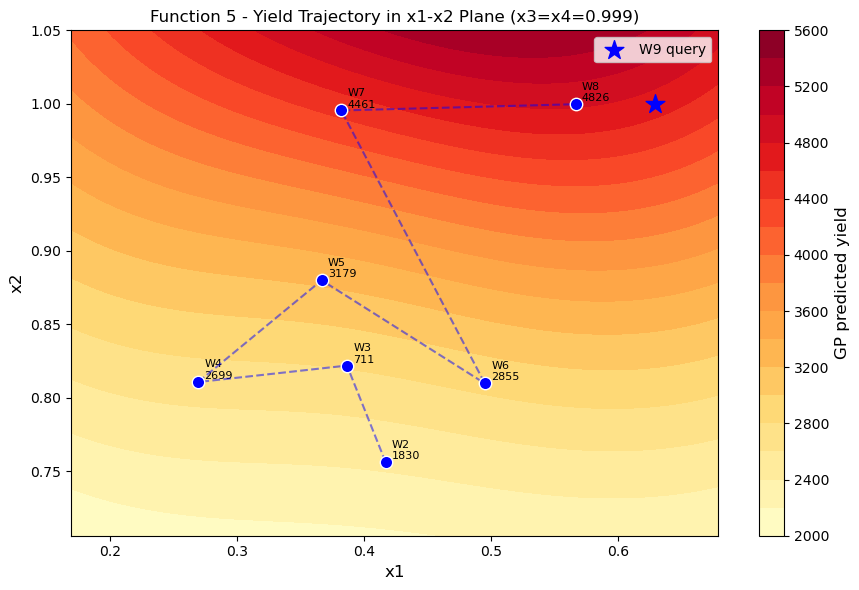

In [42]:

pad = 0.05
x1_min = min(prev_queries_F5[:, 0].min(), query_F5[0]) - 0.1
x1_max = max(prev_queries_F5[:, 0].max(), query_F5[0]) + pad
x2_min = min(prev_queries_F5[:, 1].min(), query_F5[1]) - pad
x2_max = max(prev_queries_F5[:, 1].max(), query_F5[1]) + pad

grid_n = 80
x1_range = np.linspace(x1_min, x1_max, grid_n)
x2_range = np.linspace(x2_min, x2_max, grid_n)
X1_g, X2_g = np.meshgrid(x1_range, x2_range)

grid_4d = np.column_stack([X1_g.ravel(), X2_g.ravel(),
                           np.full(grid_n**2, 0.999999),
                           np.full(grid_n**2, 0.999999)])
mu_grid = np.expm1(gp_F5.predict(grid_4d))
mu_grid = mu_grid.reshape(grid_n, grid_n)

fig, ax = plt.subplots(figsize=(9, 6))
cf = ax.contourf(X1_g, X2_g, mu_grid, levels=20, cmap='YlOrRd')
cbar = fig.colorbar(cf)
cbar.set_label('GP predicted yield', fontsize=12)

# annotate should be i+2
for i in range(len(prev_queries_F5)):
    ax.scatter(prev_queries_F5[i, 0], prev_queries_F5[i, 1], c='blue',
               edgecolors='white', s=80, zorder=5)
    ax.annotate(f'W{i+2}\n{prev_outputs_F5[i]:.0f}',
                (prev_queries_F5[i, 0] + 0.005, prev_queries_F5[i, 1] + 0.002), fontsize=8)
ax.plot(prev_queries_F5[:, 0], prev_queries_F5[:, 1], 'b--', alpha=0.5, zorder=4)
ax.scatter(query_F5[0], query_F5[1], marker='*', c='blue', s=200, zorder=10, label='W9 query')

ax.set_xlim(x1_min, x1_max)
ax.set_ylim(x2_min, x2_max)
ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_title('Function 5 - Yield Trajectory in x1-x2 Plane (x3=x4=0.999)')
ax.legend()
fig.tight_layout()
plt.show()

# # Function 6 A cake recipe, 5D array, 20 original samples - Week 9

In [43]:
# =============================================================================
# # Function 6 A cake recipe, 5D array, 20 original samples
# =============================================================================
# Previous weeks
# W3: ARD GP + EI (ξ = 0.05) over a mixed candidate pool consisting of uniform random samples, 
#     Latin Hypercube Sampling (LHS), and perturbations around the top five recipes.
# W4: GP with ARD Matérn + EI (ξ = 0.02)
# W5: RF surrogate (200 trees); acquisition via Thompson sampling 
#     using a single randomly selected decision tree rather than the ensemble mean
# W6: Random Forest (500 trees); Maximin LHS candidate design; Full-ensemble UCB
# W7: Random Forest Max depth = 5 (new); UCB κ = 1.5; the first explicit regularisation of the RF model
# W8: Hybrid GP + RF (inverse-RMSE weighted blend) + EI with multi-restart L-BFGS-B optimization

# change: Select the surrogate model via cross-validation and use SHAP values 
#         to confidently target search directions in complex 5D space.
 
print("\n" + "=" * 60)
print("Function 6 - Week 9")
print("=" * 60)

f6_inputs  = np.load('initial_data/function_6/initial_inputs.npy')
f6_outputs = np.load('initial_data/function_6/initial_outputs.npy')

prev_queries_F6 = np.array([
    [0.939456, 0.643603, 0.531941, 1.031640, 0.012391],              # W2
    [0.463219, 0.306404, 0.635240, 0.999844, 0.015672],              # W3 (GP EI)
    [0.344063, 0.007363, 0.627449, 0.999999, 0.004891],              # W4
    [0.611853, 0.139494, 0.292145, 0.366362, 0.456070],              # W5
    [0.362372, 0.287752, 0.659391, 0.946547, 0.011897],              # W6 (Full-ensemble UCB, collect predictions from every tree)
    [0.119239, 0.206322, 0.998767, 0.816254, 0.063518],              # W7 (full-ensemble UCB with Maximum LHS candidates)
    [0.471908, 0.343816, 1.000000, 0.988610, 0.154640],              # W8 (GP LOO-CV RMSE shows better than RF)

])
prev_outputs_F6 = np.array([-1.241946,         # W2 (fail)
                            -0.352945,         # W3 (above initial best)
                            -0.837300,         # W4 (fail)
                            -1.468430,         # W5 (fail)
                            -0.454581,         # W6 (above initial best)
                            -0.859304,         # W7 (fail)
                            -0.650775,         # W8 (above initial best)
                           ])

all_inputs_F6  = np.vstack([f6_inputs, prev_queries_F6])
all_outputs_F6 = np.hstack([f6_outputs, prev_outputs_F6])

print(f"Total observations: {all_inputs_F6.shape[0]}, best (max): {all_outputs_F6.max():.4f}")


Function 6 - Week 9
Total observations: 27, best (max): -0.3529


In [44]:
# Grid-search SVR hyperparameters (gamma, C, epsilon) for Function 6 
# using leave-one-out cross-validation, tracking MAE, R2, 
# and error on the top-3 best-performing points, to pick the best-calibrated configuration.

loo = LeaveOneOut()
best_pts = np.argsort(all_outputs_F6)[-3:]

gammas = [0.05, 0.1, 0.2, 0.5, 1.0]
Cs = [1, 10, 50]
epsilons = [0.01, 0.05, 0.1]

print("\nSVR Hyperparameter LOO Grid")
print(f"{'config':<28} {'MAE':>7} {'R2':>7} {'MSE@top3':>10}")
print("-" * 54)

best_r2 = -999
best_config = ""

for g in gammas:
    for c in Cs:
        for e in epsilons:
            loo_preds = np.zeros(len(all_outputs_F6))
            for train_idx, test_idx in loo.split(all_inputs_F6):
                svr_loo = Pipeline([
                    ('scl', StandardScaler()),
                    ('svr', SVR(kernel='rbf', C=c, gamma=g, epsilon=e))
                ])
                svr_loo.fit(all_inputs_F6[train_idx], all_outputs_F6[train_idx])
                loo_preds[test_idx] = svr_loo.predict(all_inputs_F6[test_idx].reshape(1, -1))[0]

            errors = all_outputs_F6 - loo_preds
            mae = np.mean(np.abs(errors))
            r2 = 1 - np.sum(errors**2) / np.sum((all_outputs_F6 - all_outputs_F6.mean())**2)
            mse_top3 = errors[best_pts].mean()

            label = f"g={g} C={c} e={e}"
            marker = ""
            if r2 > best_r2:
                best_r2 = r2
                best_config = label
                marker = " *"
            print(f"{label:<28} {mae:>7.4f} {r2:>7.4f} {mse_top3:>+10.4f}{marker}")

print(f"\nBest by R2: {best_config} (R2={best_r2:.4f})") 


SVR Hyperparameter LOO Grid
config                           MAE      R2   MSE@top3
------------------------------------------------------
g=0.05 C=1 e=0.01             0.1976  0.7583    +0.2619 *
g=0.05 C=1 e=0.05             0.2066  0.7466    +0.2779
g=0.05 C=1 e=0.1              0.2040  0.7519    +0.2303
g=0.05 C=10 e=0.01            0.1868  0.8047    +0.0236 *
g=0.05 C=10 e=0.05            0.1582  0.8463    +0.0284 *
g=0.05 C=10 e=0.1             0.1508  0.8373    +0.0686
g=0.05 C=50 e=0.01            0.2521  0.6900    -0.0850
g=0.05 C=50 e=0.05            0.1605  0.8495    +0.0053 *
g=0.05 C=50 e=0.1             0.1506  0.8376    +0.0671
g=0.1 C=1 e=0.01              0.1680  0.8216    +0.1143
g=0.1 C=1 e=0.05              0.1684  0.8160    +0.1194
g=0.1 C=1 e=0.1               0.1721  0.8044    +0.1444
g=0.1 C=10 e=0.01             0.1932  0.8057    -0.0375
g=0.1 C=10 e=0.05             0.1555  0.8458    +0.0297
g=0.1 C=10 e=0.1              0.1568  0.8240    +0.0940
g=0.1 C=50 e

In [45]:
# Fit the selected SVR configuration on all Function 6 data, 
# generate a Latin Hypercube candidate set for good space coverage, and 
# pick the candidate with the highest predicted value as the Week 9 query.

print("=" * 60)
print("Function 6 - Week 9")
print("=" * 60)

svr_F6 = Pipeline([('scl', StandardScaler()), ('svr', SVR(kernel='rbf', C=10, gamma=0.05, epsilon=0.05))])
svr_F6.fit(all_inputs_F6, all_outputs_F6)

space      = Space([(0.0, 1.0)] * 5)
lhs        = Lhs(criterion="maximin", iterations=100)
candidates_F6 = np.array(lhs.generate(space.dimensions, 5000))

svr_preds_F6 = svr_F6.predict(candidates_F6)
best_index_F6 = np.argmax(svr_preds_F6)
query_F6 = candidates_F6[best_index_F6]

print(f"\nWeek 9 Query (SVR): {format_query(query_F6)}")
print(f"  Predicted value: {svr_preds_F6[best_index_F6]:.4f}")

Function 6 - Week 9

Week 9 Query (SVR): 0.413741-0.432049-0.797573-0.842822-0.064421
  Predicted value: -0.3917


C:\Users\mayzu\AppData\Local\Temp\ipykernel_2552\2687959931.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, all_inputs_F6,


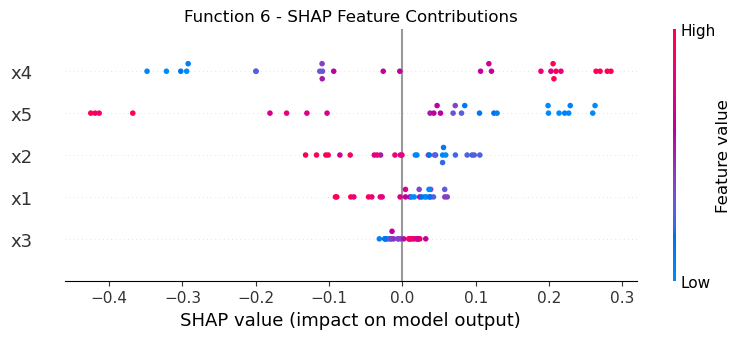

In [46]:
# Fit a Random Forest on Function 6 data and use SHAP to visualise 
# how each feature contributes to the model's predictions.

rf_F6 = RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_leaf=2, random_state=42)
rf_F6.fit(all_inputs_F6, all_outputs_F6)

explainer   = shap.TreeExplainer(rf_F6)
shap_values = explainer.shap_values(all_inputs_F6)
 
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, all_inputs_F6,
                  feature_names=[f'x{i+1}' for i in range(5)], show=False)
plt.title('Function 6 - SHAP Feature Contributions')
plt.tight_layout()
plt.show()

# # Function 7, Unspecified field, 6D array, 30 original samples - Week 9

In [47]:
# =============================================================================
# Function 7, Unspecified field, 6D array, 30 original samples
# =============================================================================
# Previous weeks
# W3: Strong exploitation vis Random Forest + SHAP identifies influential variables and preferred directions
# W4: GP EI (on log1p outputs, ξ = 0.01) + MLP regressor (50/50 blend)
# W5: Two-stage approach: RBF interpolator (multiquadric kernel) scores the full candidate set, 
#     then RF re-ranks the top 1,000 candidates
# W6: RF (importance) → ARD GP; Importance-driven subspace narrowing; UCB, multi-start L-BFGS-B
# W7: Two Random Forests → subspace → GP + UCB; Subspace bounds; UCB κ = 2
#     RF-based filtering isolated the dominant HP1 region before GP optimisation
# W8: Two-stage RF filtering (full RF → filtered RF) → GP + UCB (κ = 1.5)

# change: Filter datasets prior to model fitting to prevent correlated feature artefacts 
#         from distorting Random Forest feature importance.

print("\n" + "=" * 60)
print("Function 7 - Week 9")
print("=" * 60)

f7_inputs  = np.load('initial_data/function_7/initial_inputs.npy')
f7_outputs = np.load('initial_data/function_7/initial_outputs.npy')

prev_queries_F7 = np.array([
    [0.079933, 0.633654, 0.734486, 0.864915, 0.103811, 0.933346],    # W2
    [0.020000, 0.229276, 0.478532, 0.247457, 0.365999, 0.737383],    # W3
    [0.012357, 0.162903	, 0.399853, 0.082758, 0.249752, 0.923732],   # W4
    [0.042283, 0.348468, 0.793617, 0.259525, 0.456849, 0.822122],    # W5
    [0.020000, 0.084621, 0.685565, 0.148317, 0.347709, 0.669559],    # W6
    [0.063339, 0.123643, 0.074385, 0.373415, 0.318790, 0.765081],    # W7
    [0.002711, 0.256031, 0.238702, 0.111803, 0.341715, 0.769368],    # W8
])
prev_outputs_F7 = np.array([0.59279,                  # W2 (fail)
                            2.59480,                  # W3 (above initial max, so far the best)
                            1.08804,                  # W4 (fail)
                            1.31103,                  # W5 (fail)
                            2.130313,                 # W6 (above initial max)
                            2.06359,                  # W7 (above initial max)
                            1.642928,                 # W8 (above initial max)
                           ])

all_inputs_F7  = np.vstack([f7_inputs, prev_queries_F7])
all_outputs_F7 = np.hstack([f7_outputs, prev_outputs_F7])
log_outputs_F7 = np.log1p(all_outputs_F7)

print(f"Total points: {len(all_outputs_F7)}, best (max): {all_outputs_F7.max():.4f}")


Function 7 - Week 9
Total points: 37, best (max): 2.5948


In [48]:
feature_names = [f"HP{i+1}" for i in range(6)]

# --- Step 1a: Full-dataset Random Forest
print("\nStep 1a: Full-dataset Random Forest")
rf_full = RandomForestRegressor(n_estimators=200, random_state=42)
rf_full.fit(all_inputs_F7, all_outputs_F7)

print("\nFull-dataset RF importance:")
for name, imp in zip(feature_names, rf_full.feature_importances_):
    print(f"  {name}: {imp:.3f}")


Step 1a: Full-dataset Random Forest

Full-dataset RF importance:
  HP1: 0.820
  HP2: 0.046
  HP3: 0.027
  HP4: 0.015
  HP5: 0.037
  HP6: 0.054


In [49]:
# Fit a Random Forest on a filtered subset of Function 7 data 
# (points where HP1 is below a threshold) and compare its feature importances against 
# the full-dataset RF, to see how importance shifts once HP1's dominance is removed.

hp1_threshold = 0.08
print(f"\nStep 1b: Filtered Random Forest + SHAP (HP1 < {hp1_threshold} subset)")
hp1_mask = all_inputs_F7[:, 0] < hp1_threshold
filtered_inputs  = all_inputs_F7[hp1_mask]
filtered_outputs = all_outputs_F7[hp1_mask]

print(f"Points with HP1 < {hp1_threshold}: {hp1_mask.sum()}")
print(f"Output range in subset: {filtered_outputs.min():.3f} to {filtered_outputs.max():.3f}")

rf_filtered = RandomForestRegressor(n_estimators=200, random_state=42)
rf_filtered.fit(filtered_inputs, filtered_outputs)

print("\nFiltered RF importance:")
for name, imp_full, imp_filt in zip(feature_names, rf_full.feature_importances_, rf_filtered.feature_importances_):
    change = "***" if abs(imp_filt - imp_full) > 0.1 else ""
    print(f"  {name}: {imp_filt:.3f}  (was {imp_full:.3f} in full dataset) {change}")


Step 1b: Filtered Random Forest + SHAP (HP1 < 0.08 subset)
Points with HP1 < 0.08: 10
Output range in subset: 0.009 to 2.595

Filtered RF importance:
  HP1: 0.177  (was 0.820 in full dataset) ***
  HP2: 0.197  (was 0.046 in full dataset) ***
  HP3: 0.053  (was 0.027 in full dataset) 
  HP4: 0.161  (was 0.015 in full dataset) ***
  HP5: 0.092  (was 0.037 in full dataset) 
  HP6: 0.319  (was 0.054 in full dataset) ***


In [50]:
# Compare permutation importance against impurity-based importance for 
# both the full-dataset RF and the HP1-filtered RF, 
# since impurity importance can be misleading when features are correlated.

print("\nPermutation vs impurity importance (full dataset):")
perm_full = permutation_importance(rf_full, all_inputs_F7, all_outputs_F7,
                                    n_repeats=30, random_state=42)
print(f"  {'Feature':<8} {'Impurity':>10} {'Permutation':>12} {'Perm std':>10}")
for i, name in enumerate(feature_names):
    print(f"  {name:<8} {rf_full.feature_importances_[i]:>10.3f} "
          f"{perm_full.importances_mean[i]:>12.3f} {perm_full.importances_std[i]:>10.3f}")

print("\nPermutation vs impurity importance (filtered HP1 < 0.1):")
perm_filt = permutation_importance(rf_filtered, filtered_inputs, filtered_outputs,
                                    n_repeats=30, random_state=42)
print(f"  {'Feature':<8} {'Impurity':>10} {'Permutation':>12} {'Perm std':>10}")
for i, name in enumerate(feature_names):
    print(f"  {name:<8} {rf_filtered.feature_importances_[i]:>10.3f} "
          f"{perm_filt.importances_mean[i]:>12.3f} {perm_filt.importances_std[i]:>10.3f}")



Permutation vs impurity importance (full dataset):
  Feature    Impurity  Permutation   Perm std
  HP1           0.820        1.657      0.267
  HP2           0.046        0.048      0.012
  HP3           0.027        0.017      0.005
  HP4           0.015        0.010      0.004
  HP5           0.037        0.035      0.009
  HP6           0.054        0.060      0.016

Permutation vs impurity importance (filtered HP1 < 0.1):
  Feature    Impurity  Permutation   Perm std
  HP1           0.177        0.118      0.050
  HP2           0.197        0.135      0.056
  HP3           0.053        0.015      0.006
  HP4           0.161        0.130      0.046
  HP5           0.092        0.056      0.015
  HP6           0.319        0.399      0.138


In [51]:
# Compute SHAP values for the filtered RF model as 
# a further diagnostic on feature contributions within the HP1-filtered subset.

explainer_filtered = shap.TreeExplainer(rf_filtered)
shap_filtered = explainer_filtered.shap_values(filtered_inputs)

print("\nSHAP analysis (filtered RF, diagnostic):")
print(f"  {'Feature':<8} {'|SHAP|':>8} {'Mean SHAP':>10}")
for name, abs_s, mean_s in zip(feature_names, np.abs(shap_filtered).mean(axis=0), shap_filtered.mean(axis=0)):
    print(f"  {name:<8} {abs_s:>8.3f} {mean_s:>+10.3f}")



SHAP analysis (filtered RF, diagnostic):
  Feature    |SHAP|  Mean SHAP
  HP1         0.109     +0.009
  HP2         0.121     -0.001
  HP3         0.013     +0.001
  HP4         0.115     +0.016
  HP5         0.048     +0.024
  HP6         0.246     +0.005


In [52]:
# Stage 1 of a two-stage candidate filtering pipeline: 
# generate 100,000 random candidates and keep the 10,000 predicted best by the full-dataset RF.

print("\nStep 2: Sequential RF Filtering")

np.random.seed(42)
n_initial = 100000
candidates_F7 = np.random.uniform(0, 1, size=(n_initial, 6))

full_preds = rf_full.predict(candidates_F7)
top10k_idx = np.argsort(full_preds)[-10000:]
stage1 = candidates_F7[top10k_idx]

print(f"\nStage 1: Full RF {n_initial} -> 10,000 candidates")
print(f"  Predicted output range: [{full_preds[top10k_idx].min():.3f}, {full_preds[top10k_idx].max():.3f}]")


Step 2: Sequential RF Filtering

Stage 1: Full RF 100000 -> 10,000 candidates
  Predicted output range: [0.454, 2.180]


In [53]:
# Stage 2: from the 10,000 stage-1 candidates, 
# keep only the 1,000 predicted best by the HP1-filtered RF, 
# further narrowing the search region.

filt_preds = rf_filtered.predict(stage1)
top1k_idx = np.argsort(filt_preds)[-1000:]
stage2 = stage1[top1k_idx]
stage2_preds = filt_preds[top1k_idx]

print(f"Stage 2: Filtered RF 10,000 -> 1,000 candidates")
print(f"  Predicted output range: [{stage2_preds.min():.3f}, {stage2_preds.max():.3f}]")
print(f"\n  Feature ranges in final candidate pool:")
for i, name in enumerate(feature_names):
    print(f"    {name}: [{stage2[:, i].min():.3f}, {stage2[:, i].max():.3f}]  mean={stage2[:, i].mean():.3f}")

Stage 2: Filtered RF 10,000 -> 1,000 candidates
  Predicted output range: [1.796, 2.218]

  Feature ranges in final candidate pool:
    HP1: [0.000, 0.069]  mean=0.031
    HP2: [0.001, 0.893]  mean=0.143
    HP3: [0.000, 0.997]  mean=0.512
    HP4: [0.000, 0.997]  mean=0.342
    HP5: [0.000, 1.000]  mean=0.498
    HP6: [0.002, 0.771]  mean=0.375


In [54]:
# Fit a GP (Matern kernel, on log1p-transformed outputs) for Function 7, 
# to be used for final acquisition scoring on the doubly RF-filtered candidates.

print("\nStep 3: GP with UCB (on 1,000 RF-filtered candidates)")

kernel_F7 = ConstantKernel(1.0, (0.01, 10.0)) * Matern(
    length_scale=[0.3] * 6,
    length_scale_bounds=(0.05, 5.0),
    nu=2.5,
)
gp_F7 = GaussianProcessRegressor(
    kernel=kernel_F7,
    n_restarts_optimizer=20,
    normalize_y=True,
)
gp_F7.fit(all_inputs_F7, np.log1p(all_outputs_F7))


Step 3: GP with UCB (on 1,000 RF-filtered candidates)


,kernel,"1**2 * Matern... 0.3], nu=2.5)"
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,20
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,"Matern(length... 0.3], nu=2.5)"
,kernel__k1__constant_value,1.0


In [55]:
# Score the 1,000 RF-filtered candidates with the GP using UCB, 
# select the top-scoring point as the Week 9 query, and report its predicted value/uncertainty.

print("=" * 60)
print("Function 7 - Week 9")
print("=" * 60)

kappa_F7 = 1.5
mu_F7, sigma_F7 = gp_F7.predict(stage2, return_std=True)
ucb_F7 = mu_F7 + kappa_F7 * sigma_F7

best_idx_F7 = np.argmax(ucb_F7)
best_candidate_F7 = stage2[best_idx_F7]

predicted_mean_F7, predicted_std_F7 = gp_F7.predict(best_candidate_F7.reshape(1, -1), return_std=True)
predicted_y = np.expm1(predicted_mean_F7[0])

print(f"\nWeek 9 Query: {format_query(best_candidate_F7)}")
print(f"\nGP predicted Y (original scale) : {predicted_y:.4f}")
print(f"GP uncertainty (log scale std)  : {predicted_std_F7[0]:.4f}")
print(f"UCB score (log scale)           : {ucb_F7[best_idx_F7]:.4f}")

Function 7 - Week 9

Week 9 Query: 0.059517-0.056546-0.864985-0.258438-0.352116-0.678089

GP predicted Y (original scale) : 2.6310
GP uncertainty (log scale std)  : 0.0538
UCB score (log scale)           : 1.3703


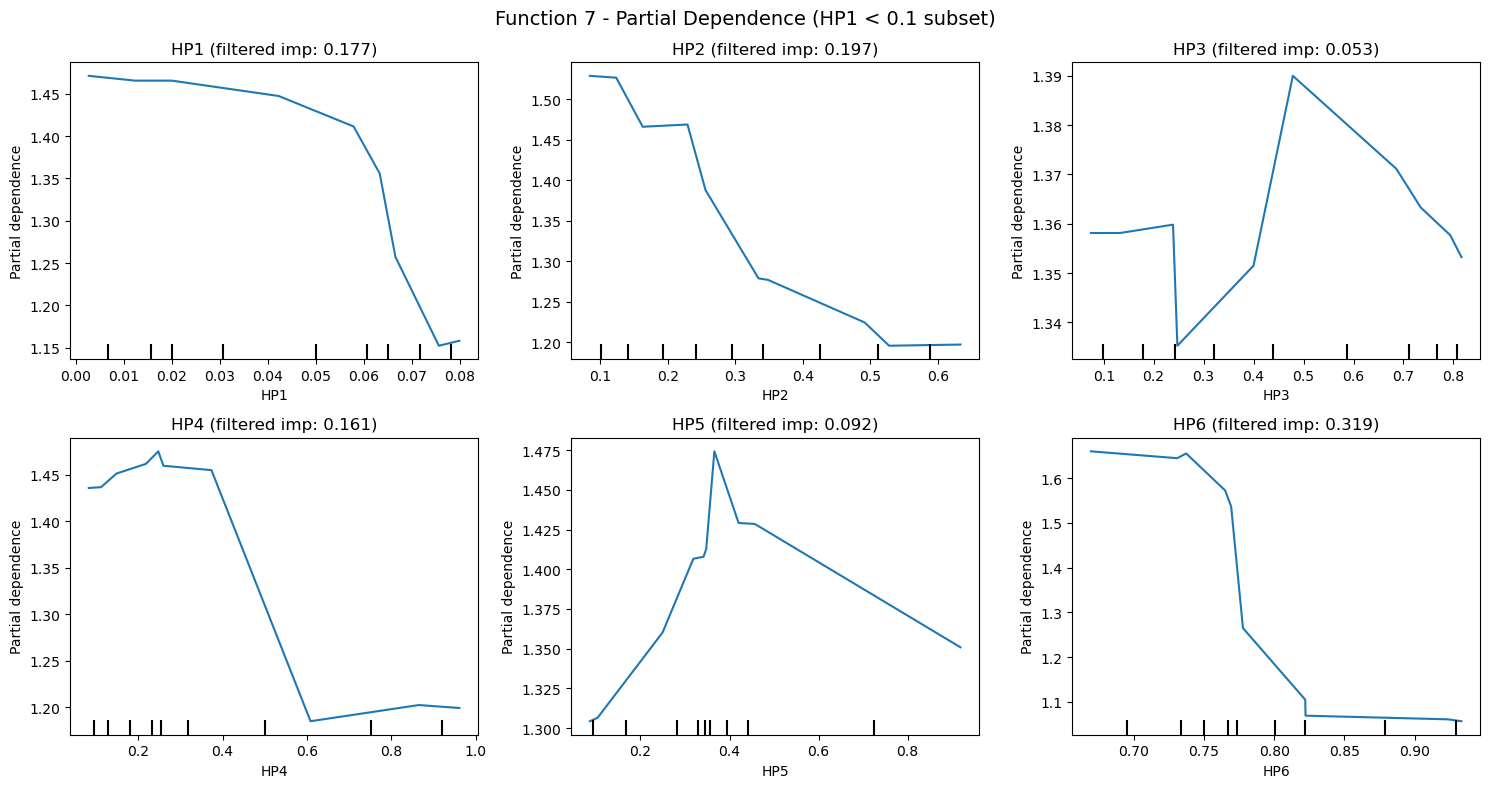

In [56]:
# Plot partial dependence for each of the 6 features using the filtered Random Forest.

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    PartialDependenceDisplay.from_estimator(rf_filtered, filtered_inputs,
                                             features=[i],
                                             feature_names=feature_names, ax=ax)
    ax.set_title(f'{feature_names[i]} (filtered imp: {rf_filtered.feature_importances_[i]:.3f})')
plt.suptitle('Function 7 - Partial Dependence (HP1 < 0.1 subset)', fontsize=14)
plt.tight_layout()
plt.show()

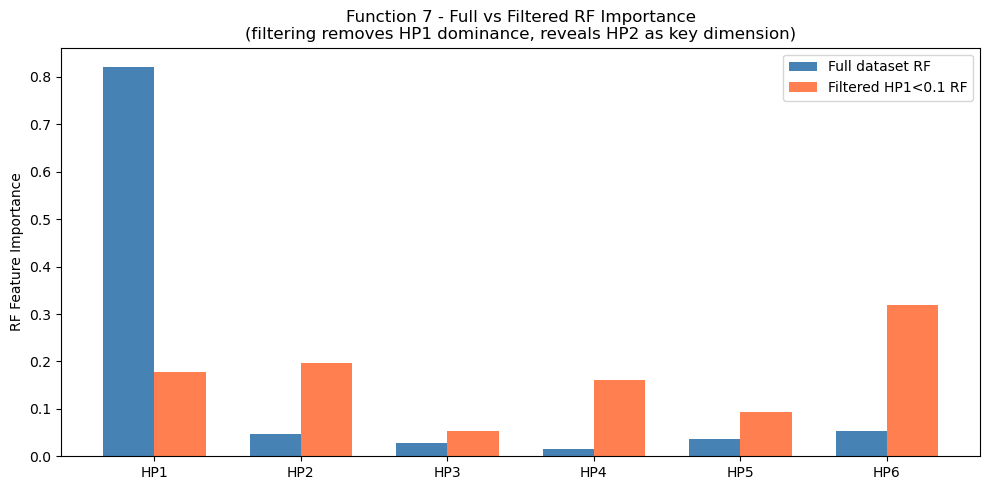

In [57]:
# Bar chart comparing feature importances between the full-dataset RF and 
# the HP1-filtered RF, to visualise how filtering shifts which feature matters most.

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(6)
width_bar = 0.35
ax.bar(x_pos - width_bar/2, rf_full.feature_importances_, width_bar, label='Full dataset RF', color='steelblue')
ax.bar(x_pos + width_bar/2, rf_filtered.feature_importances_, width_bar, label='Filtered HP1<0.1 RF', color='coral')
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names)
ax.set_ylabel('RF Feature Importance')
ax.set_title('Function 7 - Full vs Filtered RF Importance\n(filtering removes HP1 dominance, reveals HP2 as key dimension)')
ax.legend()
plt.tight_layout()
plt.show()

# # Function 8, Unspecified field, 8D array, 40 original samples - Week 9

In [58]:
# =============================================================================
# Function 8, Unspecified field, 8D array, 40 original samples
# =============================================================================
# Previous weeks
# W3: Pipeline (a) combines partial exploration (free dimensions) with strong exploitation (pinned dimensions); 
#     Pipeline (b) is almost entirely exploitation-focused.
# W4: GP (ARD Matérn) UCB (κ = 2.0) + MLP regressor (50/50 blend)
# W5: MC-Dropout MLP (2 hidden layers, dropout active during inference with 50 stochastic forward passes); acquisition = UCB (κ = 3.0)
# W6: Dropout MLP (8→24→24→1); Standard scaling; UCB via MC-dropout uncertainty
# W7: MC-Dropout MLP; Dropout = 0.2; hidden units = 24; UCB κ = 1.7; SHAP-scaled noise; 
#     HAP-informed candidate generation to guide exploration
# W8: MC-Dropout MLP + UCB with adaptive κ (κ_base × calibration ratio)

# change: Utilise Monte Carlo Dropout neural networks for calibrated uncertainty estimates, 
#        support aggressive exploration in high-dimensional spaces.

print("\n" + "=" * 60)
print("Function 8 - Week 9")
print("=" * 60)

f8_inputs  = np.load('initial_data/function_8/initial_inputs.npy')
f8_outputs = np.load('initial_data/function_8/initial_outputs.npy')

prev_queries_F8 = np.array([
    [0.034736, 0.033935, 0.577646, 0.735810, 0.807192, 0.026536, 0.72178, 0.629862],     #W2
    [0.019981, 0.000000, 0.999999, 0.000000, 0.448273, 0.855526, 0.446219, 0.931836],    #W3
    [0.035148, 0.000000, 0.018976, 0.000000, 0.999999, 0.361194, 0.007310, 0.000000],    #W4
    [0.040725, 0.748531, 0.178080, 0.981020, 0.988831, 0.993927, 0.013038, 0.216952],    #W5
    [0.060495, 0.027090, 0.006185, 0.132068, 0.160719, 0.354431, 0.001361, 0.931902],    #W6
    [0.000000, 0.009147, 0.046571, 0.113147, 0.150211, 0.340739, 0.038068, 0.928497],    #W7
    [0.007786, 0.000000, 0.000000, 0.000000, 0.999999, 0.368073, 0.022080, 0.018153],    #W7
])
prev_outputs_F8 = np.array([8.26488,                    #W2 (fail)
                            7.35099,                    #W3 (fail)
                            9.76008,                    #W4 (above initial max, so far the best)
                            8.590830,                   #W5 (fail)
                            9.619999,                   #W6 (above initial max)
                            9.638210,                   #W7 (above initial max)
                            9.752723,                   #W8 (above initial max)
                           ])

all_inputs_F8  = np.vstack([f8_inputs, prev_queries_F8])
all_outputs_F8 = np.hstack([f8_outputs, prev_outputs_F8])

print(f"Total points: {len(all_outputs_F8)}, best: {all_outputs_F8.max():.4f}")


Function 8 - Week 9
Total points: 47, best: 9.7601


In [59]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_sc = scaler_x.fit_transform(all_inputs_F8)
Y_sc = scaler_y.fit_transform(all_outputs_F8.reshape(-1, 1)).ravel()

X_tensor = torch.tensor(X_sc, dtype=torch.float32)
Y_tensor = torch.tensor(Y_sc, dtype=torch.float32).unsqueeze(1)

# MLP: hidden=24, dropout=0.25 (increased from 0.2 for better calibration)
class DropoutMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x)

In [60]:
# Leave-one-out calibration loop for Function 8: for each held-out point, 
# train a fresh DropoutMLP from scratch on the remaining data, 
# get its Monte Carlo dropout prediction (mean/std) on the held-out point, 
# and record the prediction error alongside the predicted uncertainty.

loo_errors = []
loo_sigmas = []

for i in range(len(all_outputs_F8)):
    X_train_loo = np.delete(all_inputs_F8, i, axis=0)
    y_train_loo = np.delete(all_outputs_F8, i)
    X_test_loo  = all_inputs_F8[i:i+1]
    y_test_loo  = all_outputs_F8[i]

    sx_loo = StandardScaler()
    sy_loo = StandardScaler()
    X_tr_sc_loo = sx_loo.fit_transform(X_train_loo)
    y_tr_sc_loo = sy_loo.fit_transform(y_train_loo.reshape(-1, 1)).ravel()
    X_te_sc_loo = sx_loo.transform(X_test_loo)

    X_tr_tensor = torch.tensor(X_tr_sc_loo, dtype=torch.float32)
    Y_tr_tensor = torch.tensor(y_tr_sc_loo, dtype=torch.float32).unsqueeze(1)
    X_te_tensor = torch.tensor(X_te_sc_loo, dtype=torch.float32)

    torch.manual_seed(42)
    model_loo     = DropoutMLP(input_dim=8, hidden_dim=24, dropout_rate=0.25)
    optimiser_loo = torch.optim.Adam(model_loo.parameters(), lr=1e-3)

    model_loo.train()
    for epoch in range(1000):
        optimiser_loo.zero_grad()
        loss_loo = nn.MSELoss()(model_loo(X_tr_tensor), Y_tr_tensor)
        loss_loo.backward()
        optimiser_loo.step()

    mu_sc_loo, sigma_sc_loo = mc_predict(model_loo, X_te_tensor, n_passes=100)
    mu_loo    = sy_loo.inverse_transform(mu_sc_loo.reshape(-1, 1)).ravel()[0]
    sigma_loo = np.atleast_1d(sigma_sc_loo)[0] * sy_loo.scale_[0]

    loo_errors.append(abs(mu_loo - y_test_loo))
    loo_sigmas.append(sigma_loo)

loo_errors = np.array(loo_errors)
loo_sigmas = np.array(loo_sigmas)

In [61]:
# Use the ratio of mean LOO error to mean LOO sigma 
# to calibrate an adaptive UCB kappa (so the reported uncertainty better reflects true error), 
# then train the final DropoutMLP on the full Function 8 dataset.

kappa_base = 1.7
cal_ratio  = loo_errors.mean() / loo_sigmas.mean()
kappa_F8   = kappa_base * cal_ratio

print(f"\nLOO Calibration (dropout=0.25):")
print(f"  mean |error|:        {loo_errors.mean():.4f}")
print(f"  std  |error|:        {loo_errors.std():.4f}")
print(f"  max  |error|:        {loo_errors.max():.4f}")
print(f"  mean sigma (LOO):    {loo_sigmas.mean():.4f}")
print(f"  ratio (error/sigma): {cal_ratio:.3f}  (1.0 = perfect calibration)")
print(f"  kappa (adaptive):    {kappa_F8:.2f}")

torch.manual_seed(42)
model     = DropoutMLP(input_dim=8, hidden_dim=24, dropout_rate=0.25)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

model.train()
for epoch in range(1000):
    optimiser.zero_grad()
    pred = model(X_tensor)
    loss = loss_fn(pred, Y_tensor)
    loss.backward()
    optimiser.step()

print(f"Training loss (final): {loss.item():.4f}")


LOO Calibration (dropout=0.25):
  mean |error|:        0.2986
  std  |error|:        0.3030
  max  |error|:        1.1844
  mean sigma (LOO):    0.2792
  ratio (error/sigma): 1.070  (1.0 = perfect calibration)
  kappa (adaptive):    1.82
Training loss (final): 0.0956


  0%|          | 0/47 [00:00<?, ?it/s]

C:\Users\mayzu\AppData\Local\Temp\ipykernel_2552\3144831825.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sc,


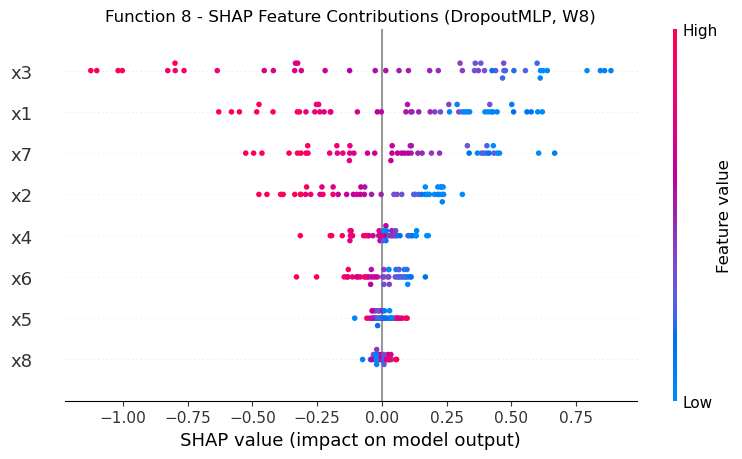

In [62]:
# Wrap the trained MLP in a numpy-in/numpy-out function so SHAP's KernelExplainer can query it, 
# then compute and plot SHAP values to see feature contributions.

model.eval()

def mlp_predict(X_np):
    """Wrapper for SHAP -- takes numpy array, returns numpy predictions."""
    X_t = torch.tensor(X_np, dtype=torch.float32)
    with torch.no_grad():
        preds = model(X_t).squeeze().numpy()
    return np.atleast_1d(preds)

background = X_sc[np.random.choice(len(X_sc), size=20, replace=False)]
explainer  = shap.KernelExplainer(mlp_predict, background)
shap_values = explainer.shap_values(X_sc, nsamples=100)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sc,
                  feature_names=[f'x{i+1}' for i in range(8)], show=False)
plt.title('Function 8 - SHAP Feature Contributions (DropoutMLP, W8)')
plt.tight_layout()
plt.show()

In [63]:
# Normalize the mean absolute SHAP values into a 0-1 importance score per feature.
model.train()  

shap_importance = np.abs(shap_values).mean(axis=0)
shap_importance = shap_importance / shap_importance.max()

print("\nSHAP-derived importance (normalised):")
for i in range(8):
    print(f"  x{i+1}: {shap_importance[i]:.3f}")


SHAP-derived importance (normalised):
  x1: 0.638
  x2: 0.394
  x3: 1.000
  x4: 0.153
  x5: 0.064
  x6: 0.153
  x7: 0.508
  x8: 0.046


In [64]:
# Identify the best-performing point observed so far, to use as the anchor point
# for local refinement search.

w4_point = all_inputs_F8[np.argmax(all_outputs_F8)]
print(f"\nRefinement anchor (W4): {w4_point} -> {all_outputs_F8.max():.4f}")


Refinement anchor (W4): [0.035148 0.       0.018976 0.       0.999999 0.361194 0.00731  0.      ] -> 9.7601


In [65]:
# Build a refinement candidate pool ('Pool A') by adding Gaussian noise around the anchor point, 
# scaling the noise per dimension based on that dimension's SHAP importance
#  (more important dimensions get larger perturbations).
np.random.seed(42)

pool_a_noise = np.random.randn(35000, 8)
for dim in range(8):
    if shap_importance[dim] > 0.5:
        pool_a_noise[:, dim] *= 0.025 + 0.015 * shap_importance[dim]
    else:
        pool_a_noise[:, dim] *= 0.005 + 0.005 * shap_importance[dim]

pool_a = np.clip(w4_point + pool_a_noise, 0, 1)

In [66]:
# Build a second candidate pool ('Pool B') that fully sweeps x3 while jittering
# x1 and x7 moderately around the anchor and fixing x2, x4, x5, x8 at fixed
# values; then combine Pool A and Pool B into the final candidate pool.

pool_b = np.zeros((15000, 8))
pool_b[:, 2] = np.random.uniform(0, 1, 15000)          # x3: full sweep
pool_b[:, 0] = np.clip(w4_point[0] + np.random.randn(15000) * 0.15, 0, 1)  # x1: moderate noise
pool_b[:, 6] = np.clip(w4_point[6] + np.random.randn(15000) * 0.15, 0, 1)  # x7: moderate noise
pool_b[:, 1] = 0.0   # x2
pool_b[:, 3] = 0.0   # x4
pool_b[:, 4] = 1.0   # x5
pool_b[:, 5] = np.clip(w4_point[5] + np.random.randn(15000) * 0.02, 0, 1)  # x6: tight jitter
pool_b[:, 7] = 0.0   # x8

pool = np.vstack([pool_a, pool_b])
print(f"Candidate pool: {len(pool_a)} refinement + {len(pool_b)} x3-sweep = {len(pool)} total")

Candidate pool: 35000 refinement + 15000 x3-sweep = 50000 total


In [67]:
print("=" * 60)
print("Function 8 - Week 9")
print("=" * 60)

# scale and predict
pool_sc     = scaler_x.transform(pool)
pool_tensor = torch.tensor(pool_sc, dtype=torch.float32)

mu_sc, sigma_sc = mc_predict(model, pool_tensor, n_passes=100)

mu_F8    = scaler_y.inverse_transform(mu_sc.reshape(-1, 1)).ravel()
sigma_F8 = sigma_sc * scaler_y.scale_[0]

# UCB with adaptive kappa
ucb_F8      = mu_F8 + kappa_F8 * sigma_F8
best_idx_F8 = np.argmax(ucb_F8)
query_F8    = pool[best_idx_F8]

# report which pool the query came from
pool_source = "Pool A (refinement)" if best_idx_F8 < len(pool_a) else "Pool B (x3-sweep)"

print(f"\nmu   range: {mu_F8.min():.3f} to {mu_F8.max():.3f}")
print(f"sigma range: {sigma_F8.min():.3f} to {sigma_F8.max():.3f}")
print(f"kappa*sigma range: {(kappa_F8*sigma_F8).min():.3f} to {(kappa_F8*sigma_F8).max():.3f}")

print(f"\nWeek 9 Query: {format_query(query_F8)}")
print(f"Source: {pool_source}")
print(f"MC mu: {mu_F8[best_idx_F8]:.4f}, sigma: {sigma_F8[best_idx_F8]:.4f}")
print(f"UCB:   {ucb_F8[best_idx_F8]:.4f}")

Function 8 - Week 9

mu   range: 8.007 to 9.862
sigma range: 0.189 to 0.448
kappa*sigma range: 0.344 to 0.815

Week 9 Query: 0.047391-0.007650-0.000000-0.000294-0.999999-0.356493-0.000000-0.000000
Source: Pool A (refinement)
MC mu: 9.7734, sigma: 0.4425
UCB:   10.5781


# Week 9 — Fidelity Metrics (Surrogate Mimicry of Black-Box Predictions)

For each function's Week-9 submission, this notebook compares the surrogate model's
**predicted mean / sigma at the query it submitted** against the **true black-box value**
that was returned for that query.

Three numbers are computed per function:

- **Raw error** = `true − predicted` (predicted mean back-transformed to the black box's raw output scale)
- **Relative error %** = `raw_error / |true|  ×  100`
- **z-score** = `error / sigma`, computed in whichever scale sigma is actually valid in
  (some surrogates — F1, F5, F7 — report mean/sigma on a transformed scale, not the raw scale)

`|z| < 1` → well-calibrated · `|z| > 2` → the surrogate's uncertainty estimate was too tight.


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)


## 1. Inputs

Predicted mean / sigma exactly as printed in each function's Week-9 submission cell.
`scale` records what space the reported numbers live in:

| scale | meaning |
|---|---|
| `raw` | reported mean and sigma are already on the black box's raw output scale |
| `arcsinh` | reported mean/sigma are on `arcsinh(y / eps)` space (F1's sign-preserving transform) |
| `log1p` | reported **mean** has already been back-transformed to raw by the notebook, but the reported **sigma** is still on `log1p(y)` space (F5, F7) |

**F4 has two rows** — the notebook computed an exploration-leaning (UCB) candidate and an
exploitation-leaning candidate but never recorded which one was actually submitted. Both are
scored here; drop the wrong one once you confirm which query went in.

**F6 has `sigma = NaN`** — its SVR surrogate produced only a point prediction, with no
uncertainty estimate, so no z-score is possible for it.


In [69]:
rows = [
    dict(fn="F1",             pred=8.60,      sigma=10.81,   true=6.88e-15,     scale="arcsinh", eps=1e-20,
         note="Raw outputs span ~200 orders of magnitude; GP trained on arcsinh(y/eps)."),
    dict(fn="F2",             pred=0.677,     sigma=0.054,   true=0.636072868,  scale="raw",     eps=None,
         note="GP (Matern+White), EI/explore strategy chosen."),
    dict(fn="F3",             pred=-0.094925, sigma=0.071064,true=-0.02926924,  scale="raw",     eps=None,
         note="ExtraTrees on poly features, UCB submission. True value near zero -> relative % is misleading, use z instead."),
    dict(fn="F4-A (UCB)",     pred=0.246,     sigma=0.713,   true=0.47213001,   scale="raw",     eps=None,
         note="AMBIGUOUS: notebook never recorded which of the two candidates was actually submitted."),
    dict(fn="F4-B (exploit)", pred=0.350,     sigma=0.526,   true=0.47213001,   scale="raw",     eps=None,
         note="AMBIGUOUS: notebook never recorded which of the two candidates was actually submitted."),
    dict(fn="F5",             pred=4699.22,   sigma=0.1350,  true=5022.767512,  scale="log1p",   eps=None,
         note="SVR pre-filter -> GP on log1p(yield). Mean already back-transformed; sigma stays on log1p scale."),
    dict(fn="F6",             pred=-0.3917,   sigma=np.nan,  true=-0.338381312, scale="raw",     eps=None,
         note="SVR point prediction only -- no uncertainty estimate exists, so no z-score is possible."),
    dict(fn="F7",             pred=2.6310,    sigma=0.0538,  true=2.749208025,  scale="log1p",   eps=None,
         note="Two-stage RF filtering -> GP on log1p(Y). Mean already back-transformed; sigma stays on log1p scale."),
    dict(fn="F8",             pred=9.7734,    sigma=0.4425,  true=9.730201369,  scale="raw",     eps=None,
         note="MC-Dropout MLP, adaptive-kappa UCB. Best-calibrated function this week."),
]

print(f"{len(rows)} function submissions loaded")


9 function submissions loaded


## 2. Transform-aware helper functions

`sigma` is only meaningful in the scale the surrogate actually predicted in, so the true value (and, where needed, the predicted mean) must be moved into that same scale before computing a z-score. Separately, the raw error needs everything back on the black box's native output scale.


In [70]:
def native_true(row):
    """True value expressed in whichever scale sigma actually lives in."""
    if row["scale"] == "arcsinh":
        return np.arcsinh(row["true"] / row["eps"])
    if row["scale"] == "log1p":
        return np.log1p(row["true"])
    return row["true"]

def native_pred(row):
    """Predicted mean expressed in the native (sigma) scale."""
    if row["scale"] == "arcsinh":
        return row["pred"]                 # already native
    if row["scale"] == "log1p":
        return np.log1p(row["pred"])       # pred was reported already back-transformed to raw
    return row["pred"]

def raw_pred(row):
    """Predicted mean back-transformed to the black box's raw output scale."""
    if row["scale"] == "arcsinh":
        return row["eps"] * np.sinh(row["pred"])
    return row["pred"]                     # raw and log1p cases: pred is already raw

print("helper functions defined")


helper functions defined


## 3. Compute Raw error, Relative error %, and z-score


In [71]:
records = []
for r in rows:
    raw_error = r["true"] - raw_pred(r)
    rel_error_pct = 100 * raw_error / abs(r["true"])
    err_native = native_true(r) - native_pred(r)
    z = err_native / r["sigma"] if not np.isnan(r["sigma"]) else np.nan
    records.append(dict(
        Function=r["fn"],
        Predicted_Mean=r["pred"],
        Sigma=r["sigma"],
        True_Value=r["true"],
        Raw_Error=raw_error,
        Relative_Error_pct=rel_error_pct,
        z_score=z,
        Notes=r["note"],
    ))

df = pd.DataFrame.from_records(records)
pd.set_option("display.float_format", lambda v: f"{v:,.6g}")
df[["Function", "Predicted_Mean", "Sigma", "True_Value", "Raw_Error", "Relative_Error_pct", "z_score"]]


,Function,Predicted_Mean,Sigma,True_Value,Raw_Error,Relative_Error_pct,z_score
0,F1,8.6,10.81,6.88e-15,6.85284e-15,99.6053,0.511997
1,F2,0.677,0.054,0.636073,-0.0409271,-6.43435,-0.75791
2,F3,-0.094925,0.071064,-0.0292692,0.0656558,224.317,0.923896
3,F4-A (UCB),0.246,0.713,0.47213,0.22613,47.8957,0.317153
4,F4-B (exploit),0.35,0.526,0.47213,0.12213,25.8679,0.232186
5,F5,"4,699.22",0.135,"5,022.77",323.548,6.44162,0.493117
6,F6,-0.3917,NaN,-0.338381,0.0533187,15.757,NaN
7,F7,2.631,0.0538,2.74921,0.118208,4.29971,0.595475
8,F8,9.7734,0.4425,9.7302,-0.0431986,-0.443964,-0.097624


## 4. z-score chart across functions

Bars outside the dashed ±1σ band mean the surrogate's uncertainty estimate was too tight for the error it actually made; well inside the band (like **F8**) means the model's own uncertainty estimate was a good predictor of how far off it would be. **F6** has no bar since it has no sigma at all.


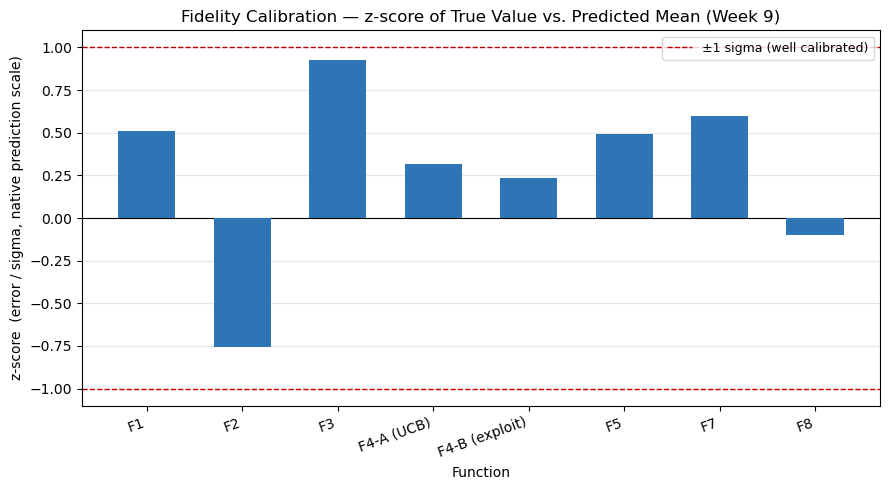

In [72]:
plot_df = df.dropna(subset=["z_score"])

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(plot_df["Function"], plot_df["z_score"], color="#2E75B6", width=0.6, zorder=3)
ax.axhline(1, color="#C00000", linestyle="--", linewidth=1, label="±1 sigma (well calibrated)")
ax.axhline(-1, color="#C00000", linestyle="--", linewidth=1)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("z-score  (error / sigma, native prediction scale)")
ax.set_xlabel("Function")
ax.set_title("Fidelity Calibration — z-score of True Value vs. Predicted Mean (Week 9)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.3, zorder=0)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 5. Note

- **F4** is scored under both candidate queries because the Week-9 notebook never recorded
  which one was actually submitted — confirm the real query and drop the other row.
- **F6** has no uncertainty estimate in the original notebook (SVR point prediction only),
  so its z-score is `NaN` by design, not a bug.
- **F1's relative error % (≈100%) looks alarming but is an artifact of comparing values near
  1e-15** — the z-score (0.51σ) is the honest read: the GP was actually well-calibrated in
  its native `arcsinh` space.
- **F3's relative error % (≈224%) is similarly misleading** for the same near-zero-denominator
  reason; use its z-score (0.92σ) instead.
